#A Multimodal AI System for PCOS Prediction Using Ultrasound Images and Clinical Data



## System Architecture

```
┌─────────────────────────────────────────────────────┐
│              IMAGE PREPROCESSING PIPELINE            │
│  Gaussian Blur → CLAHE Enhancement → Edge Sharpening │
└─────────────────────────────────────────────────────┘
                         ↓
┌─────────────────────────────────────────────────────┐
│         ULTRASOUND IMAGE MODEL (Unimodal)           │
│         EfficientNet-B0 + Transfer Learning         │
│       Binary Classification: Infected / Non-Infected│
└─────────────────────────────────────────────────────┘
                         ↓
                   P_image(PCOS)
                         ↓
┌─────────────────────────────────────────────────────┐
│       CLINICAL TABULAR MODEL (Unimodal)             │
│       Gradient Boosting + Random Forest + LR        │
│       Binary Classification: PCOS / Non-PCOS        │
└─────────────────────────────────────────────────────┘
                         ↓
                  P_tabular(PCOS)
                         ↓
┌─────────────────────────────────────────────────────┐
│         DECISION-LEVEL FUSION (Late Fusion)         │
│    Final = w_img × P_img + w_tab × P_tab            │
│    Threshold = 0.5 for binary decision              │
└─────────────────────────────────────────────────────┘
```

---

## Image Preprocessing Pipeline

```
Original → Gaussian Blur → CLAHE Enhanced → Sharpened → Final
             (Noise)       (Contrast)       (Edges)
```

**Techniques Used:**
1. **Gaussian Blur (5×5)** - Reduces noise and smooths speckle
2. **CLAHE** - Contrast Limited Adaptive Histogram Equalization
3. **Edge Sharpening** - Enhances follicle boundaries
4. **Normalization** - Scales to [0, 1] range

---

## Dataset Structure

```
Dataset/
├── train/
│   ├── infected/           # PCOS training images
│   └── non_infected/       # Non-PCOS training images
├── test/
│   ├── infected/           # PCOS test images
│   └── non_infected/       # Non-PCOS test images
└── PCOS Dataset.xlsx       # Clinical tabular data
```


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")
print("📂 Access your dataset at: /content/drive/MyDrive/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
📂 Access your dataset at: /content/drive/MyDrive/


##Import Libraries & Set Reproducibility

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob
from tqdm import tqdm
import cv2
from scipy import ndimage

warnings.filterwarnings('ignore')


RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # TensorFlow specific
    import tensorflow as tf
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_seed(RANDOM_SEED)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)


print("=" * 60)
print("ENVIRONMENT VERIFICATION")
print("=" * 60)
print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ NumPy Version: {np.__version__}")
print(f"✅ Pandas Version: {pd.__version__}")
print(f"✅ OpenCV Version: {cv2.__version__}")
print(f"✅ Random Seed Set: {RANDOM_SEED}")


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {len(gpus)} GPU(s) detected")
    for gpu in gpus:
        print(f"   - {gpu.name}")

    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No GPU detected. Training will use CPU (slower).")

print("=" * 60)
print("✅ All imports successful!")
print("=" * 60)

ENVIRONMENT VERIFICATION
✅ TensorFlow Version: 2.19.0
✅ NumPy Version: 2.0.2
✅ Pandas Version: 2.2.2
✅ OpenCV Version: 4.12.0
✅ Random Seed Set: 42
⚠️ No GPU detected. Training will use CPU (slower).
✅ All imports successful!


## Define Dataset Paths

In [ ]:

# Base path to dataset in Google Drive
BASE_PATH = '/content/drive/MyDrive/Dataset3/'


TRAIN_INFECTED_PATH = os.path.join(BASE_PATH, 'train/infected/')      # PCOS training images
TRAIN_NON_INFECTED_PATH = os.path.join(BASE_PATH, 'train/notinfected/')  # Non-PCOS training images

# Test image paths
TEST_INFECTED_PATH = os.path.join(BASE_PATH, 'test/infected/')        # PCOS test images
TEST_NON_INFECTED_PATH = os.path.join(BASE_PATH, 'test/notinfected/')    # Non-PCOS test images


# TABULAR DATA PATH (Excel file)

TABULAR_DATA_PATH = os.path.join(BASE_PATH, 'PCOS Dataset.xlsx')

# Model save paths
MODEL_SAVE_PATH = '/content/drive/MyDrive/PCOS_Models/'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)


print("=" * 60)
print("DATASET PATH VERIFICATION")
print("=" * 60)

paths_valid = True


print("\n📂 TRAINING IMAGES:")
if os.path.exists(TRAIN_INFECTED_PATH):
    train_infected_count = len(glob(os.path.join(TRAIN_INFECTED_PATH, '*')))
    print(f"✅ Train Infected (PCOS): {TRAIN_INFECTED_PATH}")
    print(f"   Found: {train_infected_count} files")
else:
    print(f"❌ Train Infected NOT FOUND: {TRAIN_INFECTED_PATH}")
    paths_valid = False

if os.path.exists(TRAIN_NON_INFECTED_PATH):
    train_non_infected_count = len(glob(os.path.join(TRAIN_NON_INFECTED_PATH, '*')))
    print(f"✅ Train Non-Infected: {TRAIN_NON_INFECTED_PATH}")
    print(f"   Found: {train_non_infected_count} files")
else:
    print(f"❌ Train Non-Infected NOT FOUND: {TRAIN_NON_INFECTED_PATH}")
    paths_valid = False

# Check test image directories
print("\n📂 TEST IMAGES:")
if os.path.exists(TEST_INFECTED_PATH):
    test_infected_count = len(glob(os.path.join(TEST_INFECTED_PATH, '*')))
    print(f"✅ Test Infected (PCOS): {TEST_INFECTED_PATH}")
    print(f"   Found: {test_infected_count} files")
else:
    print(f"❌ Test Infected NOT FOUND: {TEST_INFECTED_PATH}")
    paths_valid = False

if os.path.exists(TEST_NON_INFECTED_PATH):
    test_non_infected_count = len(glob(os.path.join(TEST_NON_INFECTED_PATH, '*')))
    print(f"✅ Test Non-Infected: {TEST_NON_INFECTED_PATH}")
    print(f"   Found: {test_non_infected_count} files")
else:
    print(f"❌ Test Non-Infected NOT FOUND: {TEST_NON_INFECTED_PATH}")
    paths_valid = False

# Check Excel file
print("\n📂 TABULAR DATA:")
if os.path.exists(TABULAR_DATA_PATH):
    print(f"✅ Excel File: {TABULAR_DATA_PATH}")
else:
    print(f"❌ Excel File NOT FOUND: {TABULAR_DATA_PATH}")
    paths_valid = False

print("\n" + "=" * 60)
if paths_valid:
    print("✅ All dataset paths verified successfully!")
else:
    print("⚠️ Some paths not found. Please check BASE_PATH variable.")
print("=" * 60)

DATASET PATH VERIFICATION

📂 TRAINING IMAGES:
✅ Train Infected (PCOS): /content/drive/MyDrive/Dataset3/train/infected/
   Found: 781 files
✅ Train Non-Infected: /content/drive/MyDrive/Dataset3/train/notinfected/
   Found: 1143 files

📂 TEST IMAGES:
✅ Test Infected (PCOS): /content/drive/MyDrive/Dataset3/test/infected/
   Found: 781 files
✅ Test Non-Infected: /content/drive/MyDrive/Dataset3/test/notinfected/
   Found: 1145 files

📂 TABULAR DATA:
✅ Excel File: /content/drive/MyDrive/Dataset3/PCOS Dataset.xlsx

✅ All dataset paths verified successfully!


---

# 🖼️ PART 1: IMAGE MODEL (Unimodal)

## EfficientNet-B0 with Transfer Learning

**Architecture:** EfficientNet-B0 pretrained on ImageNet  
**Strategy:** Two-phase training (freeze backbone → fine-tune last layers)  

**Dataset Structure:**
```
Dataset/
├── train/
│   ├── infected/      ← PCOS training images
│   └── non_infected/  ← Non-PCOS training images
└── test/
    ├── infected/      ← PCOS test images
    └── non_infected/  ← Non-PCOS test images
```

---

##Image Data Preprocessing

**Processing Pipeline:**
- Load images from pre-split train/test folders
- Resize images to 224×224 (EfficientNet input size)
- Normalize pixel values to [0, 1]
- Create validation split from training data
- Apply data augmentation (training only)

In [ ]:
# Image parameters (EfficientNet-B0 standard input)
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 32


def load_image_data(infected_path, not_infected_path, img_size=IMG_SIZE):
    """
    Load images from directories and create labels.

    Args:
        infected_path: Path to PCOS (infected) images
        not_infected_path: Path to non-PCOS (non-infected) images
        img_size: Target image size

    Returns:
        images: numpy array of images
        labels: numpy array of labels (1=PCOS/Infected, 0=Non-PCOS/Non-Infected)
        file_paths: list of file paths for reference
    """
    images = []
    labels = []
    file_paths = []

    # Load PCOS/Infected images (label = 1)
    print("Loading Infected (PCOS) images...")
    pcos_files = glob(os.path.join(infected_path, '*'))
    for img_path in tqdm(pcos_files, desc="Infected"):
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(1)  # Infected/PCOS = 1
            file_paths.append(img_path)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            continue

    # Load Non-PCOS/Non-Infected images (label = 0)
    print("Loading Non-Infected images...")
    non_pcos_files = glob(os.path.join(not_infected_path, '*'))
    for img_path in tqdm(non_pcos_files, desc="Non-Infected"):
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(0)  # Non-Infected = 0
            file_paths.append(img_path)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            continue

    return np.array(images), np.array(labels), file_paths


print("=" * 60)
print("LOADING TRAINING IMAGES")
print("=" * 60)

X_train_img_full, y_train_img_full, train_paths = load_image_data(
    TRAIN_INFECTED_PATH,
    TRAIN_NON_INFECTED_PATH
)

print(f"\n✅ Training Images Loaded: {len(X_train_img_full)}")
print(f"   Infected (PCOS): {np.sum(y_train_img_full == 1)}")
print(f"   Non-Infected: {np.sum(y_train_img_full == 0)}")


print("\n" + "=" * 60)
print("LOADING TEST IMAGES")
print("=" * 60)

X_test_img, y_test_img, test_paths = load_image_data(
    TEST_INFECTED_PATH,
    TEST_NON_INFECTED_PATH
)

print(f"\n✅ Test Images Loaded: {len(X_test_img)}")
print(f"   Infected (PCOS): {np.sum(y_test_img == 1)}")
print(f"   Non-Infected: {np.sum(y_test_img == 0)}")

print("\n" + "=" * 60)
print("IMAGE DATASET SUMMARY")
print("=" * 60)
print(f"Total Training Images: {len(X_train_img_full)}")
print(f"Total Test Images:     {len(X_test_img)}")
print(f"Image Shape:           {X_train_img_full[0].shape}")
print(f"Training Class Balance: {np.sum(y_train_img_full == 1) / len(y_train_img_full):.2%} Infected")
print(f"Test Class Balance:     {np.sum(y_test_img == 1) / len(y_test_img):.2%} Infected")
print("=" * 60)

LOADING TRAINING IMAGES
Loading Infected (PCOS) images...


Infected: 100%|██████████| 781/781 [00:06<00:00, 112.95it/s]


Loading Non-Infected images...


Non-Infected: 100%|██████████| 1143/1143 [00:39<00:00, 29.03it/s]



✅ Training Images Loaded: 1924
   Infected (PCOS): 781
   Non-Infected: 1143

LOADING TEST IMAGES
Loading Infected (PCOS) images...


...

Error loading /content/drive/MyDrive/Dataset3/test/notinfected/img_0_7.jpg: cannot identify image file '/content/drive/MyDrive/Dataset3/test/notinfected/img_0_7.jpg'


Non-Infected:  88%|████████▊ | 1010/1145 [00:32<00:02, 54.29it/s]

Error loading /content/drive/MyDrive/Dataset3/test/notinfected/WhatsApp Image 2022-04-01 at 3.35.25 PM.jpeg: cannot identify image file '/content/drive/MyDrive/Dataset3/test/notinfected/WhatsApp Image 2022-04-01 at 3.35.25 PM.jpeg'
Error loading /content/drive/MyDrive/Dataset3/test/notinfected/OIP (1).jpg: cannot identify image file '/content/drive/MyDrive/Dataset3/test/notinfected/OIP (1).jpg'
Error loading /content/drive/MyDrive/Dataset3/test/notinfected/WhatsApp Image 2022-04-01 at 3.39.07 PM.jpeg: cannot identify image file '/content/drive/MyDrive/Dataset3/test/notinfected/WhatsApp Image 2022-04-01 at 3.39.07 PM.jpeg'


Non-Infected: 100%|██████████| 1145/1145 [00:36<00:00, 31.02it/s]



✅ Test Images Loaded: 1922
   Infected (PCOS): 781
   Non-Infected: 1141

IMAGE DATASET SUMMARY
Total Training Images: 1924
Total Test Images:     1922
Image Shape:           (224, 224, 3)
Training Class Balance: 40.59% Infected
Test Class Balance:     40.63% Infected


## Medical Image Preprocessing Pipeline

**Preprocessing Steps for Ultrasound Images:**

1. **Gaussian Blur** - Reduces noise and smooths the image
2. **CLAHE Enhancement** - Improves contrast using adaptive histogram equalization
3. **Multilevel Thresholding** - Otsu's method for automatic thresholding
4. **Morphological Processing** - Removes small artifacts and fills holes

**Pipeline Diagram:**
```
Original → Gaussian Blur → CLAHE Enhanced → Preprocessed Image
```

APPLYING MEDICAL IMAGE PREPROCESSING

📸 Preprocessing Pipeline Visualization (PCOS Sample):


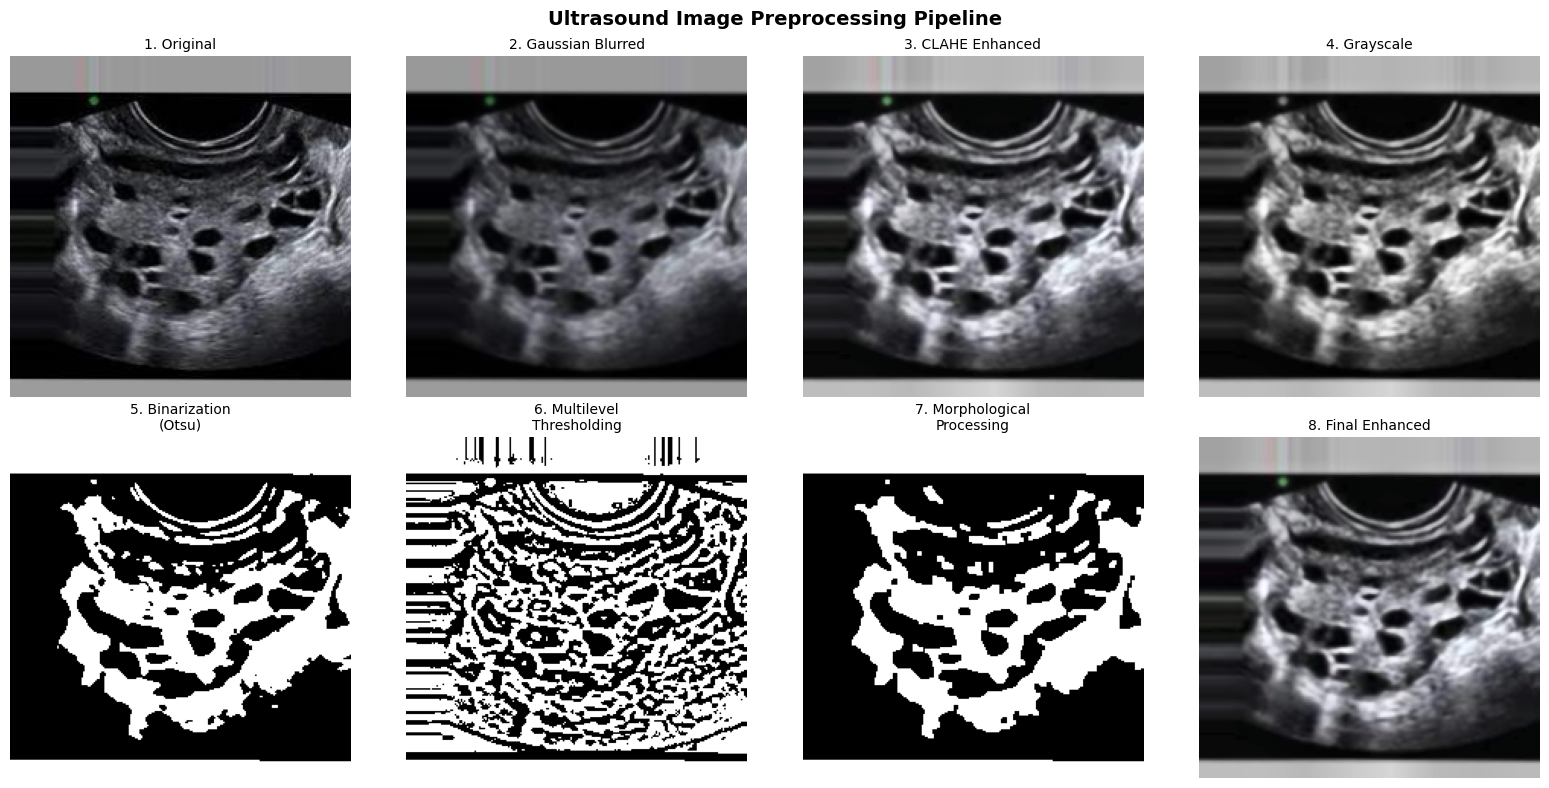


📸 Preprocessing Pipeline Visualization (Non-PCOS Sample):


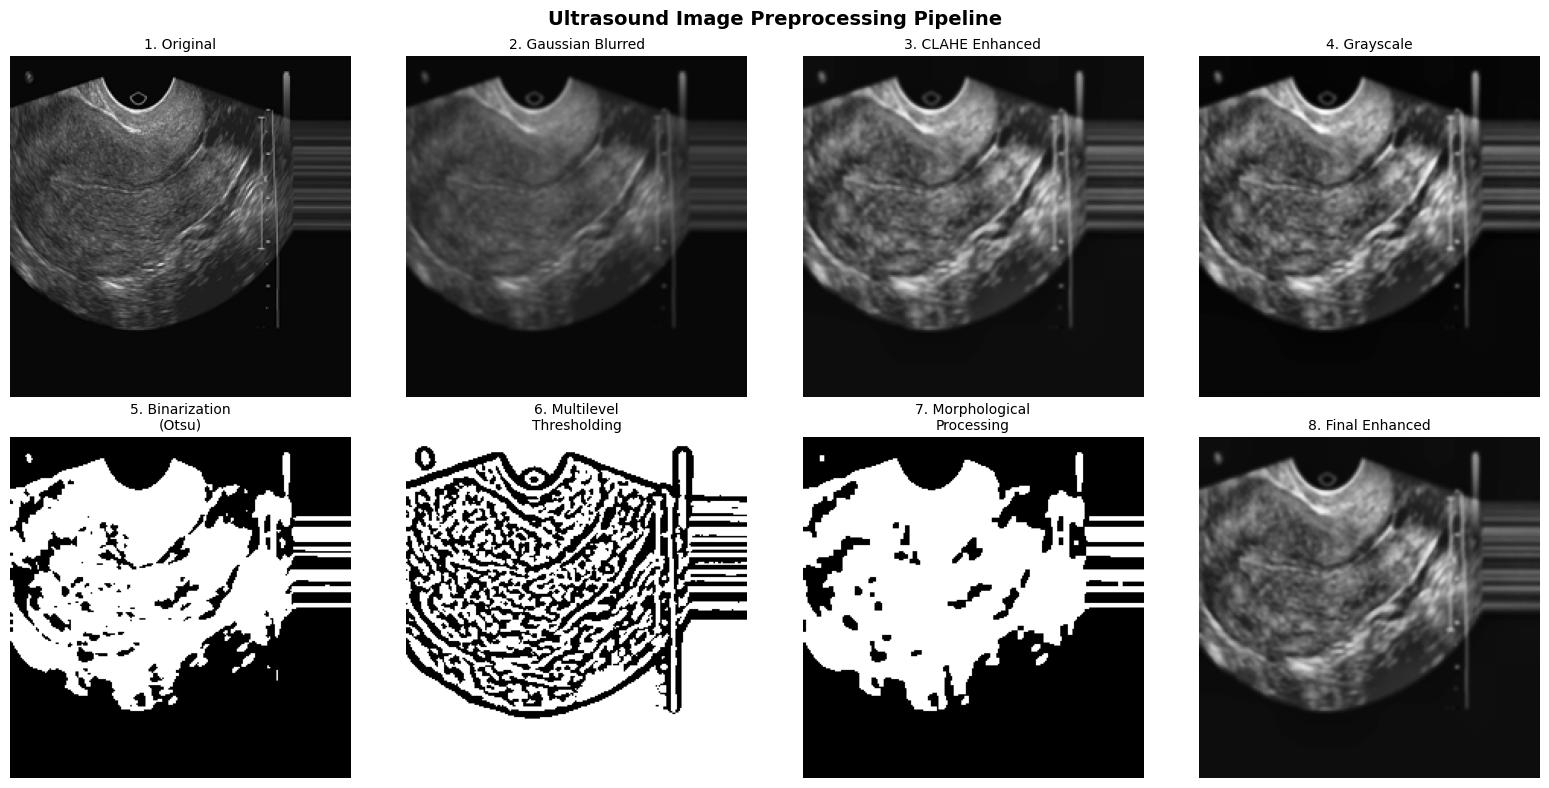


⏳ Preprocessing training images...


Training: 100%|██████████| 1924/1924 [00:06<00:00, 316.46it/s]


⏳ Preprocessing test images...


Test: 100%|██████████| 1922/1922 [00:08<00:00, 215.40it/s]



✅ Preprocessing complete!
   Training images preprocessed: 1924
   Test images preprocessed: 1922


In [ ]:

import cv2
from scipy import ndimage

def preprocess_ultrasound_image(image, apply_all=True):
    """
    Apply medical image preprocessing pipeline to ultrasound images.

    Steps:
    1. Gaussian Blur - Noise reduction
    2. CLAHE Enhancement - Adaptive histogram equalization
    3. Optional: Morphological processing

    Args:
        image: Input image as numpy array (H, W, C) normalized to [0, 1]
        apply_all: Whether to apply full preprocessing

    Returns:
        Preprocessed image normalized to [0, 1]
    """
    # Convert to uint8 for OpenCV operations
    img_uint8 = (image * 255).astype(np.uint8)

    # Gaussian Blur for noise reduction
    blurred = cv2.GaussianBlur(img_uint8, (5, 5), 0)

    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # Apply to each channel for color images
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    if len(blurred.shape) == 3:
        # For color images, convert to LAB and apply CLAHE to L channel
        lab = cv2.cvtColor(blurred, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    else:
        enhanced = clahe.apply(blurred)

    if apply_all:
        #Light sharpening to enhance edges
        kernel = np.array([[-1, -1, -1],
                          [-1,  9, -1],
                          [-1, -1, -1]])
        sharpened = cv2.filter2D(enhanced, -1, kernel)

        # Blend sharpened with enhanced (50% each) to avoid over-sharpening
        final = cv2.addWeighted(enhanced, 0.7, sharpened, 0.3, 0)
    else:
        final = enhanced

    # Normalize back to [0, 1]
    return final.astype(np.float32) / 255.0


def visualize_preprocessing_steps(image):
    """
    Visualize all preprocessing steps for a single ultrasound image.
    Replicates the pipeline shown in academic papers.
    """
    # Convert to uint8
    img_uint8 = (image * 255).astype(np.uint8)

    # Original
    original = img_uint8.copy()

    #  Gaussian Blur
    gaussian_blurred = cv2.GaussianBlur(img_uint8, (5, 5), 0)

    #  Enhanced (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if len(gaussian_blurred.shape) == 3:
        lab = cv2.cvtColor(gaussian_blurred, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    else:
        enhanced = clahe.apply(gaussian_blurred)

    # Grayscale for thresholding visualization
    gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

    #Binarization (Otsu's Thresholding)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Multilevel Thresholding (using multiple thresholds)
    # Simulate multilevel by using adaptive thresholding
    multilevel = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

    # Morphological Processing
    kernel = np.ones((3, 3), np.uint8)
    morphed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    morphed = cv2.morphologyEx(morphed, cv2.MORPH_OPEN, kernel)

    # Visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Ultrasound Image Preprocessing Pipeline', fontsize=14, fontweight='bold')

    titles = ['1. Original', '2. Gaussian Blurred', '3. CLAHE Enhanced', '4. Grayscale',
              '5. Binarization\n(Otsu)', '6. Multilevel\nThresholding', '7. Morphological\nProcessing', '8. Final Enhanced']

    images = [original, gaussian_blurred, enhanced, gray, binary, multilevel, morphed, enhanced]

    for idx, (ax, img, title) in enumerate(zip(axes.flat, images, titles)):
        if len(img.shape) == 2:  # Grayscale
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return enhanced




print("=" * 60)
print("APPLYING MEDICAL IMAGE PREPROCESSING")
print("=" * 60)


print("\n Preprocessing Pipeline Visualization (PCOS Sample):")
pcos_sample_idx = np.where(y_train_img_full == 1)[0][0]
_ = visualize_preprocessing_steps(X_train_img_full[pcos_sample_idx])

print("\n Preprocessing Pipeline Visualization (Non-PCOS Sample):")
non_pcos_sample_idx = np.where(y_train_img_full == 0)[0][0]
_ = visualize_preprocessing_steps(X_train_img_full[non_pcos_sample_idx])

# Apply preprocessing to all training images
print("\n Preprocessing training images...")
X_train_preprocessed = np.array([preprocess_ultrasound_image(img) for img in tqdm(X_train_img_full, desc="Training")])

# Apply preprocessing to all test images
print(" Preprocessing test images...")
X_test_preprocessed = np.array([preprocess_ultrasound_image(img) for img in tqdm(X_test_img, desc="Test")])

# Replace original arrays with preprocessed versions
X_train_img_full = X_train_preprocessed
X_test_img = X_test_preprocessed

print("\n Preprocessing complete!")
print(f"   Training images preprocessed: {len(X_train_img_full)}")
print(f"   Test images preprocessed: {len(X_test_img)}")
print("=" * 60)

In [ ]:
# Since data is pre-split into train/test folders:
# - Split training data into Train (85%) and Validation (15%)
# - Test data remains unchanged

X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train_img_full, y_train_img_full,
    test_size=0.15,  # 15% for validation
    stratify=y_train_img_full,
    random_state=RANDOM_SEED
)

print("=" * 60)
print("IMAGE DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training Set:   {len(X_train_img)} samples")
print(f"  - Infected: {np.sum(y_train_img == 1)}, Non-Infected: {np.sum(y_train_img == 0)}")
print(f"Validation Set: {len(X_val_img)} samples")
print(f"  - Infected: {np.sum(y_val_img == 1)}, Non-Infected: {np.sum(y_val_img == 0)}")
print(f"Test Set:       {len(X_test_img)} samples (from test folder)")
print(f"  - Infected: {np.sum(y_test_img == 1)}, Non-Infected: {np.sum(y_test_img == 0)}")
print("=" * 60)


from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_img),
    y=y_train_img
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}

print(f"\nClass Weights for Training:")
print(f"  Class 0 (Non-Infected): {class_weights[0]:.4f}")
print(f"  Class 1 (Infected):     {class_weights[1]:.4f}")

IMAGE DATA SPLIT SUMMARY
Training Set:   1635 samples
  - Infected: 664, Non-Infected: 971
Validation Set: 289 samples
  - Infected: 117, Non-Infected: 172
Test Set:       1922 samples (from test folder)
  - Infected: 781, Non-Infected: 1141

Class Weights for Training:
  Class 0 (Non-Infected): 0.8419
  Class 1 (Infected):     1.2312


✅ STRONG Data Augmentation configured (prevents overfitting)
   - Rotation: ±30° (increased)
   - Shift: ±20% (increased)
   - Shear: 20% (increased)
   - Zoom: ±20% (increased)
   - Brightness: 80%-120%
   - Horizontal Flip: Enabled


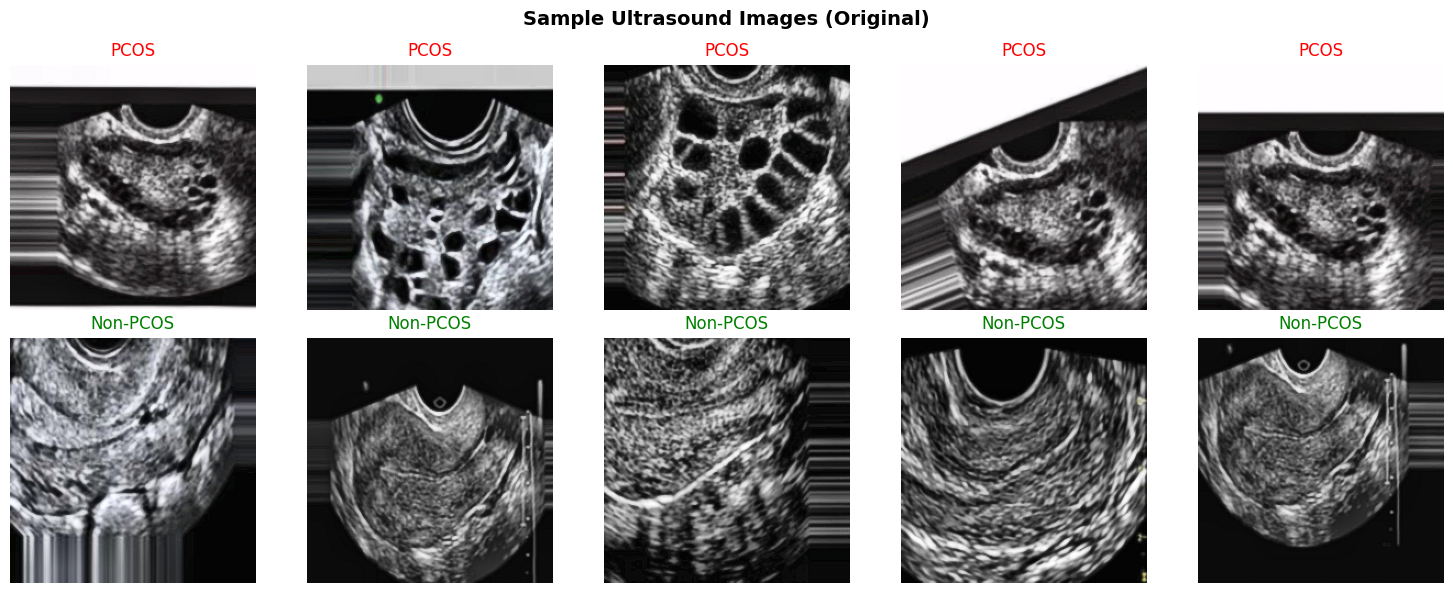


📸 Showing augmented versions of the same image:


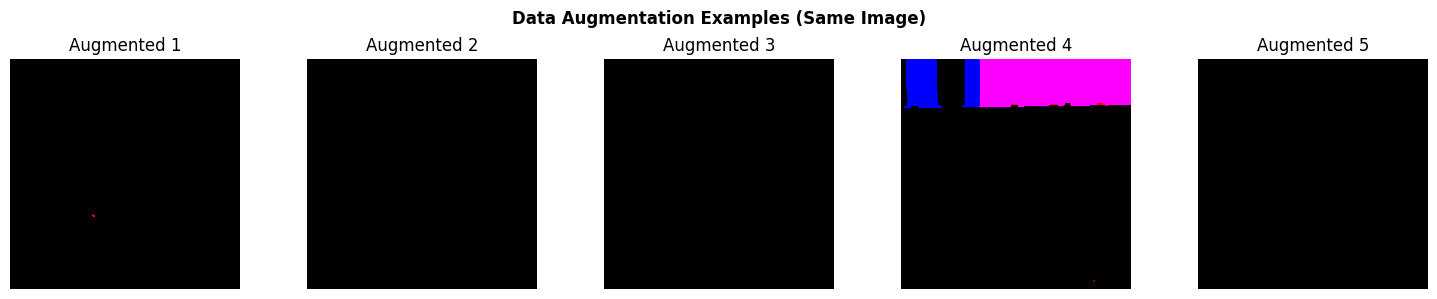

In [ ]:

train_datagen = ImageDataGenerator(
    rotation_range=30,          # Random rotation ±30 degrees (increased)
    width_shift_range=0.2,      # Random horizontal shift 20% (increased)
    height_shift_range=0.2,     # Random vertical shift 20% (increased)
    shear_range=0.2,            # Shear transformation 20% (increased)
    zoom_range=0.2,             # Random zoom 20% (increased)
    horizontal_flip=True,       # Random horizontal flip
    brightness_range=[0.8, 1.2], # Random brightness
    fill_mode='nearest'         # Fill mode for new pixels
)


val_test_datagen = ImageDataGenerator()

train_datagen.fit(X_train_img)

print("✅ STRONG Data Augmentation configured (prevents overfitting)")
print("   - Rotation: ±30° (increased)")
print("   - Shift: ±20% (increased)")
print("   - Shear: 20% (increased)")
print("   - Zoom: ±20% (increased)")
print("   - Brightness: 80%-120%")
print("   - Horizontal Flip: Enabled")



fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Ultrasound Images (Original)', fontsize=14, fontweight='bold')


pcos_indices = np.where(y_train_img == 1)[0][:5]
for i, idx in enumerate(pcos_indices):
    axes[0, i].imshow(X_train_img[idx])
    axes[0, i].set_title('PCOS', color='red')
    axes[0, i].axis('off')


non_pcos_indices = np.where(y_train_img == 0)[0][:5]
for i, idx in enumerate(non_pcos_indices):
    axes[1, i].imshow(X_train_img[idx])
    axes[1, i].set_title('Non-PCOS', color='green')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


print("\n Showing augmented versions of the same image:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_img = X_train_img[pcos_indices[0:1]]  # Take one sample
for i, batch in enumerate(train_datagen.flow(sample_img, batch_size=1)):
    if i >= 5:
        break
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples (Same Image)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

##  Build EfficientNet-B0 Image Model (Anti-Overfitting)

**Architecture Design (Robust Regularization):**
- **Base Model:** EfficientNet-B0 (pretrained on ImageNet)
- **Custom Head:** GAP → BN → Dropout(0.4) → Dense(128, L2) → BN → Dropout(0.5) → Dense(32, L2) → Dropout(0.3) → Output
- **Training Strategy:** Two-phase progressive unfreezing
- **Anti-Overfitting Techniques:**
  - L2 Regularization (weight decay = 0.01)
  - Multiple Dropout layers
  - Label Smoothing (0.1)
  - Aggressive Early Stopping

In [ ]:

# BUILD EFFICIENTNET-B0 MODEL WITH ROBUST REGULARIZATION


def build_efficientnet_model(input_shape=IMG_SHAPE, freeze_base=True):
    """
    Build EfficientNet-B0 model with STRONG regularization to prevent overfitting.

    Anti-Overfitting Techniques:
    - L2 regularization on Dense layers
    - Multiple Dropout layers (spatial + regular)
    - Batch Normalization
    - Label smoothing in loss function

    Args:
        input_shape: Input image shape (H, W, C)
        freeze_base: Whether to freeze backbone weights

    Returns:
        Compiled Keras model
    """
    # Load pretrained EfficientNet-B0 (without top layers)
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze or unfreeze base model
    base_model.trainable = not freeze_base

    # Build custom classification head with STRONG REGULARIZATION
    inputs = keras.Input(shape=input_shape)

    # Data augmentation inside model (consistent during training)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # Base model (training=False for BatchNorm inference mode when frozen)
    x = base_model(x, training=not freeze_base)

    # Global Average Pooling + Spatial Dropout
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.BatchNormalization(name='batch_norm_1')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)  # First dropout

    # Dense layer with L2 regularization
    x = layers.Dense(
        128,  # Reduced from 256 to prevent overfitting
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),  # L2 regularization
        name='dense_128'
    )(x)
    x = layers.BatchNormalization(name='batch_norm_2')(x)
    x = layers.Dropout(0.5, name='dropout_2')(x)  # Second dropout

    # Additional smaller dense layer
    x = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        name='dense_32'
    )(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)  # Third dropout

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    # Create model
    model = Model(inputs, outputs, name='EfficientNet_PCOS_Robust')

    return model, base_model

# Build the model with frozen backbone (Phase 1)
print("=" * 60)
print("BUILDING EFFICIENTNET-B0 MODEL (ROBUST ANTI-OVERFITTING)")
print("=" * 60)

image_model, base_model = build_efficientnet_model(freeze_base=True)

# Compile with LABEL SMOOTHING to prevent overconfident predictions
image_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),  # Label smoothing!
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Model summary
print("\n Model Architecture Summary (Anti-Overfitting Features):")
print("-" * 60)
print(" L2 Regularization: 0.01")
print(" Dropout Layers: 3 (0.4, 0.5, 0.3)")
print("Label Smoothing: 0.1")
print(" Reduced Dense Units: 128 → 32")
print("-" * 60)
image_model.summary()

print("\n" + "=" * 60)
print(f"Total Parameters: {image_model.count_params():,}")
print(f"Trainable Parameters: {sum([tf.keras.backend.count_params(w) for w in image_model.trainable_weights]):,}")
print("=" * 60)

BUILDING EFFICIENTNET-B0 MODEL (ROBUST ANTI-OVERFITTING)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Model Architecture Summary (Anti-Overfitting Features):
------------------------------------------------------------
✅ L2 Regularization: 0.01
✅ Dropout Layers: 3 (0.4, 0.5, 0.3)
✅ Label Smoothing: 0.1
✅ Reduced Dense Units: 128 → 32
------------------------------------------------------------


Model: "EfficientNet_PCOS_Robust"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,223,332 (16.11 MB)

 Trainable params: 170,945 (667.75 KB)

 Non-trainable params: 4,052,387 (15.46 MB)


Total Parameters: 4,223,332
Trainable Parameters: 170,945


## Train Image Model (Two-Phase Training)

**Phase 1:** Train only the custom head (frozen backbone)  
**Phase 2:** Fine-tune last layers of backbone

**Callbacks:**
- Early Stopping (patience=5)
- Learning Rate Reduction on Plateau
- Model Checkpoint (save best model)

In [ ]:


# Early stopping - MORE AGGRESSIVE to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Reduced from 5 - stop earlier
    restore_best_weights=True,
    min_delta=0.001,  # Minimum improvement required
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,  # More aggressive reduction (was 0.5)
    patience=2,  # Faster reduction
    min_lr=1e-7,
    verbose=1
)

# Save best model checkpoint
checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODEL_SAVE_PATH, 'best_image_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

print(" Anti-Overfitting Callbacks Configured:")
print("   - Early Stopping (patience=3, min_delta=0.001)")
print("   - Learning Rate Reduction (factor=0.3, patience=2)")
print("   - Model Checkpoint (save best only)")
print("\n Note: Aggressive early stopping will prevent overfitting")

✅ Anti-Overfitting Callbacks Configured:
   - Early Stopping (patience=3, min_delta=0.001)
   - Learning Rate Reduction (factor=0.3, patience=2)
   - Model Checkpoint (save best only)

⚠️ Note: Aggressive early stopping will prevent overfitting


In [ ]:

# PHASE 1: TRAIN CUSTOM HEAD (FROZEN BACKBONE)


print("=" * 60)
print("PHASE 1: Training Custom Head (Frozen EfficientNet Backbone)")
print("=" * 60)

PHASE1_EPOCHS = 10  # Reduced from 15 - less overfitting risk

# Create data generators for training with STRONGER AUGMENTATION
train_generator = train_datagen.flow(
    X_train_img, y_train_img,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Train Phase 1
history_phase1 = image_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_img) // BATCH_SIZE,
    epochs=PHASE1_EPOCHS,
    validation_data=(X_val_img, y_val_img),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print(" Phase 1 Training Complete!")
print("=" * 60)

PHASE 1: Training Custom Head (Frozen EfficientNet Backbone)
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5157 - auc: 0.5157 - loss: 3.6786
Epoch 1: val_loss improved from inf to 3.05370, saving model to /content/drive/MyDrive/PCOS_Models/best_image_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.5154 - auc: 0.5154 - loss: 3.6761 - val_accuracy: 0.4048 - val_auc: 0.5000 - val_loss: 3.0537 - learning_rate: 0.0010
Epoch 2/10
 1/51 ━━━━━━━━━━━━━━━━━━━━ 2:35 3s/step - accuracy: 0.3125 - auc: 0.2922 - loss: 3.4810
Epoch 2: val_loss improved from 3.05370 to 3.04427, saving model to /content/drive/MyDrive/PCOS_Models/best_image_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 463ms/step - accuracy: 0.3125 - auc: 0.2922 - loss: 3.4810 - val_accuracy: 0.4048 - val_auc: 0.5000 - val_loss: 3.0443 - learning_rate: 0.0010
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5081 - auc: 0.5055 - loss: 3.0956
Epoch 3: val_loss improved from 3.04427 to 2.59953, 

In [ ]:

# PHASE 2: FINE-TUNE LAST LAYERS (CONSERVATIVE)


print("=" * 60)
print("PHASE 2: Fine-tuning Last Layers (Conservative)")
print("=" * 60)

# Unfreeze ONLY the last 10 layers (more conservative than 20)
base_model.trainable = True

# Freeze all layers except the last 10
for layer in base_model.layers[:-10]:  # Reduced from -20
    layer.trainable = False

# Count trainable layers
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"📊 Fine-tuning only {trainable_count} layers of EfficientNet backbone")

# Recompile with VERY LOW learning rate for fine-tuning
image_model.compile(
    optimizer=Adam(learning_rate=0.00005),  # Very low LR (was 0.0001)
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f"\nTrainable Parameters (after unfreezing): {sum([tf.keras.backend.count_params(w) for w in image_model.trainable_weights]):,}")

PHASE2_EPOCHS = 10  # Reduced from 20

# VERY aggressive early stopping for Phase 2
early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Very aggressive
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)

callbacks_phase2 = [early_stopping_phase2, reduce_lr, checkpoint]

# Train Phase 2
history_phase2 = image_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_img) // BATCH_SIZE,
    epochs=PHASE2_EPOCHS,
    validation_data=(X_val_img, y_val_img),
    class_weight=class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n" + "=" * 60)
print("✅ Phase 2 Fine-tuning Complete!")
print("=" * 60)

PHASE 2: Fine-tuning Last Layers (Conservative)
📊 Fine-tuning only 10 layers of EfficientNet backbone

Trainable Parameters (after unfreezing): 1,064,177
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5099 - auc: 0.4988 - loss: 1.7516
Epoch 1: val_loss did not improve from 1.66826
51/51 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.5101 - auc: 0.4992 - loss: 1.7513 - val_accuracy: 0.4048 - val_auc: 0.4971 - val_loss: 1.6816 - learning_rate: 5.0000e-05
Epoch 2/10
 1/51 ━━━━━━━━━━━━━━━━━━━━ 2:15 3s/step - accuracy: 0.5312 - auc: 0.5392 - loss: 1.7488
Epoch 2: val_loss did not improve from 1.66826
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 410ms/step - accuracy: 0.5312 - auc: 0.5392 - loss: 1.7488 - val_accuracy: 0.4048 - val_auc: 0.4564 - val_loss: 1.6815 - learning_rate: 5.0000e-05
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5116 - auc: 0.5108 - loss: 1.7093
Epoch 3: val_loss improved from 1.66826 to 1.66475, saving model to /content/drive/MyDrive/PCOS_Models/be

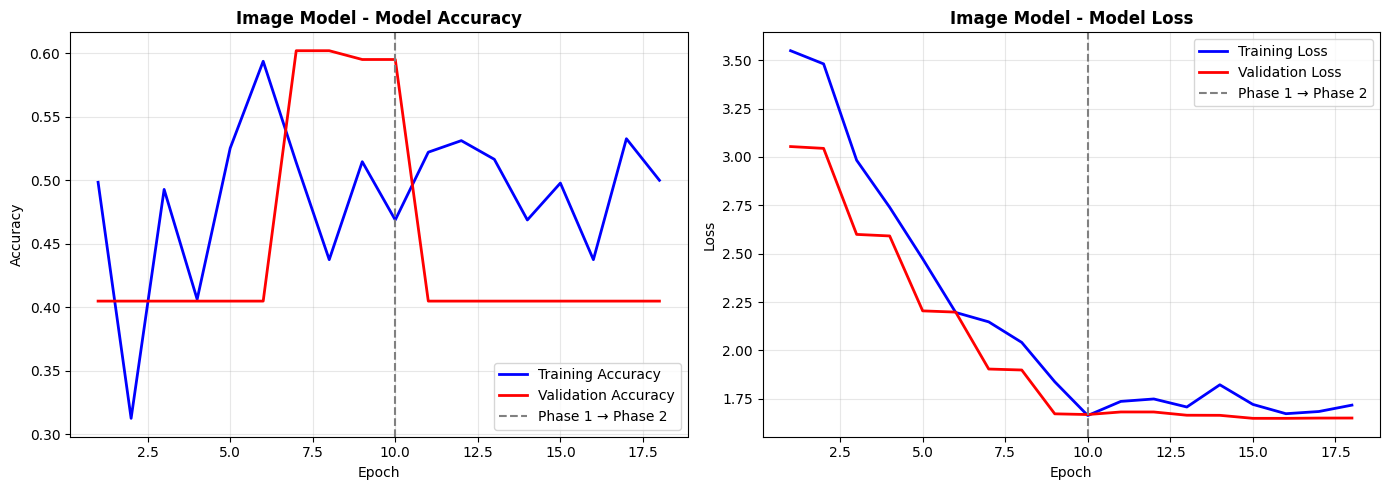

In [ ]:


def plot_training_history(history1, history2, title_prefix=""):
    """Plot training and validation metrics across both phases."""

    # Combine histories
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    phase1_end = len(history1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
    axes[0].plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    axes[0].axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 1 → Phase 2')
    axes[0].set_title(f'{title_prefix}Model Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    axes[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[1].axvline(x=phase1_end, color='gray', linestyle='--', label='Phase 1 → Phase 2')
    axes[1].set_title(f'{title_prefix}Model Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history_phase1, history_phase2, "Image Model - ")

##  Image Model Evaluation

**Metrics Computed:**
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

In [ ]:

# IMAGE MODEL EVALUATION ON TEST SET


def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Comprehensive model evaluation with all required metrics.

    Args:
        model: Trained model (Keras or sklearn)
        X_test: Test features
        y_test: Test labels
        model_name: Name for display

    Returns:
        Dictionary of metrics
    """
    # Get predictions
    if hasattr(model, 'predict_proba'):
        # Sklearn model
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)
    else:
        # Keras model
        y_proba = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_proba > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Print results
    print("=" * 60)
    print(f" {model_name} - EVALUATION RESULTS")
    print("=" * 60)
    print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("=" * 60)

    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-PCOS', 'PCOS']))

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# Evaluate image model on test set
print("\n" + "=" * 60)
print("EVALUATING IMAGE MODEL ON TEST SET")
print("=" * 60 + "\n")

image_results = evaluate_model(image_model, X_test_img, y_test_img, "EfficientNet-B0 Image Model")


EVALUATING IMAGE MODEL ON TEST SET

📊 EfficientNet-B0 Image Model - EVALUATION RESULTS
Accuracy:  0.4063  (40.63%)
Precision: 0.4063
Recall:    1.0000
F1-Score:  0.5779
ROC-AUC:   0.2755

📋 Classification Report:
              precision    recall  f1-score   support

    Non-PCOS       0.00      0.00      0.00      1141
        PCOS       0.41      1.00      0.58       781

    accuracy                           0.41      1922
   macro avg       0.20      0.50      0.29      1922
weighted avg       0.17      0.41      0.23      1922



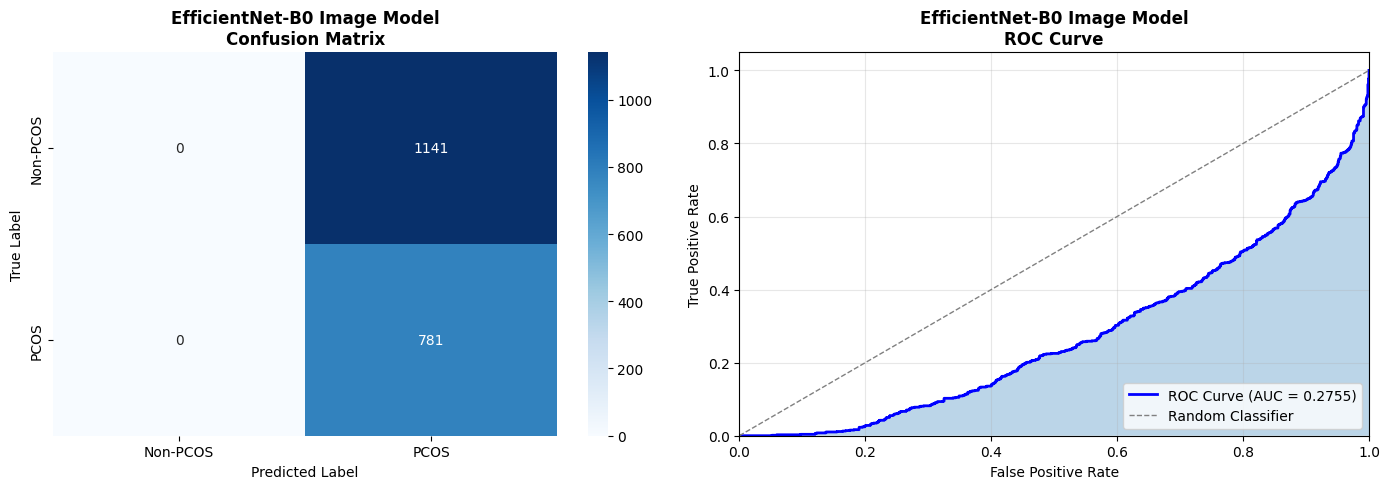

In [ ]:


def plot_evaluation_results(results, y_test, model_name="Model"):
    """Plot confusion matrix and ROC curve."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = results['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-PCOS', 'PCOS'],
                yticklabels=['Non-PCOS', 'PCOS'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
    axes[1].fill_between(fpr, tpr, alpha=0.3)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name}\nROC Curve', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot image model evaluation
plot_evaluation_results(image_results, y_test_img, "EfficientNet-B0 Image Model")

---

# TABULAR MODEL (Unimodal)

## Clinical Data Classification

**Data Source:** `PCOS Dataset.xlsx` (Excel file)

**Algorithms:**
- Logistic Regression (Baseline)
- Random Forest (Main Model)

**Preprocessing:**
- Missing value handling
- One-hot encoding for categorical variables
- Feature scaling (StandardScaler)
- Stratified train/validation/test split

---

# Tabular Data Preprocessing

In [ ]:


print("=" * 60)
print("LOADING TABULAR CLINICAL DATA")
print("=" * 60)

# Load Excel file
try:
    # Read Excel file - check for multiple sheets
    xlsx = pd.ExcelFile(TABULAR_DATA_PATH)
    print(f"📂 Excel file loaded: {TABULAR_DATA_PATH}")
    print(f"   Available sheets: {xlsx.sheet_names}")

    # Read the first sheet (or specify sheet name if known)
    if len(xlsx.sheet_names) > 0:
        # Try to read the main data sheet
        df_tabular = pd.read_excel(TABULAR_DATA_PATH, sheet_name=0)
        print(f"✅ Loaded sheet: '{xlsx.sheet_names[0]}'")

except Exception as e:
    print(f"❌ Error loading Excel file: {e}")
    df_tabular = pd.DataFrame()


# IDENTIFY OR CREATE TARGET VARIABLE

# Check for existing PCOS label column (various possible names)
possible_label_cols = ['PCOS (Y/N)', 'PCOS', 'pcos', 'Label', 'label', 'Target', 'target',
                       'PCOS_Label', 'Diagnosis', 'Class', 'Infected']

target_col = None
for col in possible_label_cols:
    if col in df_tabular.columns:
        target_col = col
        print(f"✅ Found target column: '{target_col}'")
        break

if target_col is None:
    print("⚠️ Target column not found. Displaying available columns:")
    print(df_tabular.columns.tolist())
    # You may need to manually specify the target column
else:
    # Standardize target column name
    df_tabular['PCOS_Label'] = df_tabular[target_col]

    # Convert to binary if needed (handle Y/N, Yes/No, etc.)
    if df_tabular['PCOS_Label'].dtype == 'object':
        df_tabular['PCOS_Label'] = df_tabular['PCOS_Label'].map(
            {'Y': 1, 'N': 0, 'Yes': 1, 'No': 0, 'yes': 1, 'no': 0,
             'PCOS': 1, 'Normal': 0, 1: 1, 0: 0, '1': 1, '0': 0}
        )

print("\n" + "=" * 60)
print("TABULAR DATASET SUMMARY")
print("=" * 60)
print(f"Total Records: {len(df_tabular)}")
print(f"Total Columns: {len(df_tabular.columns)}")

if 'PCOS_Label' in df_tabular.columns:
    print(f"PCOS Positive (1): {len(df_tabular[df_tabular['PCOS_Label'] == 1])}")
    print(f"PCOS Negative (0): {len(df_tabular[df_tabular['PCOS_Label'] == 0])}")
print("=" * 60)

# Display first few rows
print("\n📋 Dataset Preview:")
display(df_tabular.head())

# Display column names
print("\n📋 Available Columns:")
for i, col in enumerate(df_tabular.columns, 1):
    print(f"   {i:2d}. {col}")

LOADING TABULAR CLINICAL DATA
📂 Excel file loaded: /content/drive/MyDrive/Dataset3/PCOS Dataset.xlsx
   Available sheets: ['Sheet1']
✅ Loaded sheet: 'Sheet1'
⚠️ Target column not found. Displaying available columns:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Hip_Circumference_cm', 'Waist_Hip_Ratio', 'Age_at_Menarche', 'Menstrual_Cycle_Length_days', 'Menstrual_Irregularity', 'Gravidity', 'Parity', 'Hirsutism_Score_FG', 'Acne_Severity', 'Alopecia', 'Skin_Darkening_Acanthosis', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Physical_Activity_Level', 'Smoking_Status', 'Alcohol_Intake', 'Dietary_Sugar_Intake', 'Sleep_Hours', 'FSH_mIU_mL', 'LH_mIU_mL', 'LH_FSH_Ratio', 'Total_Testosterone_ng_dL', 'Free_Testosterone_pg_mL', 'DHEAS_ug_dL', 'Prolactin_ng_mL', 'Estradiol_pg_mL', 'Progesterone_ng_mL', 'SHBG_nmol_L', 'Fasting_Glucose_mg_dL', 'Fasting_Insulin_uIU_mL', 'HOMA_IR', 'HbA1c_percent', 'Total_Cholesterol_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL', 'Triglycerides_mg_

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Hip_Circumference_cm,Waist_Hip_Ratio,Age_at_Menarche,Menstrual_Cycle_Length_days,Menstrual_Irregularity,...,Ovary_Volume_Right_cm3,Follicle_Count_Left,Follicle_Count_Right,CRP_mg_L,ALT_U_L,AST_U_L,TSH_uIU_mL,Vitamin_D_ng_mL,Hemoglobin_g_dL,PCOS_Diagnosis
0,39,152.1,63.4,25.82,93.1,91.5,0.86,12,33,0,...,13.7,18,16,1.11,36,37,1.42,46.3,13.0,1
1,32,143.8,61.5,31.36,80.1,94.4,0.79,10,26,1,...,14.3,28,16,4.74,35,31,1.96,24.8,13.0,0
2,28,146.9,50.8,22.90,75.1,108.4,0.96,13,38,0,...,13.5,6,18,-1.55,62,41,2.17,22.2,12.2,0
3,31,165.5,69.5,23.68,75.0,74.1,0.84,10,31,1,...,18.9,7,25,4.15,56,47,-0.03,18.9,12.6,0
4,40,152.1,73.7,29.05,92.9,80.3,0.93,10,32,0,...,13.2,5,4,0.58,55,44,2.31,46.4,10.1,0



📋 Available Columns:
    1. Age
    2. Height_cm
    3. Weight_kg
    4. BMI
    5. Waist_Circumference_cm
    6. Hip_Circumference_cm
    7. Waist_Hip_Ratio
    8. Age_at_Menarche
    9. Menstrual_Cycle_Length_days
   10. Menstrual_Irregularity
   11. Gravidity
   12. Parity
   13. Hirsutism_Score_FG
   14. Acne_Severity
   15. Alopecia
   16. Skin_Darkening_Acanthosis
   17. Blood_Pressure_Systolic
   18. Blood_Pressure_Diastolic
   19. Physical_Activity_Level
   20. Smoking_Status
   21. Alcohol_Intake
   22. Dietary_Sugar_Intake
   23. Sleep_Hours
   24. FSH_mIU_mL
   25. LH_mIU_mL
   26. LH_FSH_Ratio
   27. Total_Testosterone_ng_dL
   28. Free_Testosterone_pg_mL
   29. DHEAS_ug_dL
   30. Prolactin_ng_mL
   31. Estradiol_pg_mL
   32. Progesterone_ng_mL
   33. SHBG_nmol_L
   34. Fasting_Glucose_mg_dL
   35. Fasting_Insulin_uIU_mL
   36. HOMA_IR
   37. HbA1c_percent
   38. Total_Cholesterol_mg_dL
   39. HDL_mg_dL
   40. LDL_mg_dL
   41. Triglycerides_mg_dL
   42. Ovary_Volume_Left_c

In [ ]:

# EXPLORE AND CLEAN TABULAR DATA


print("=" * 60)
print("DATA EXPLORATION & CLEANING")
print("=" * 60)

# Check data types
print("\n📋 Data Types:")
print(df_tabular.dtypes)

# Check missing values
print("\n📋 Missing Values:")
missing = df_tabular.isnull().sum()
missing_pct = (missing / len(df_tabular)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

if missing.sum() == 0:
    print("✅ No missing values found!")

# Check for duplicates
duplicates = df_tabular.duplicated().sum()
print(f"\n📋 Duplicate Rows: {duplicates}")

# Statistical summary
print("\n📋 Statistical Summary:")
df_tabular.describe()

DATA EXPLORATION & CLEANING

📋 Data Types:
Age                              int64
Height_cm                      float64
Weight_kg                      float64
BMI                            float64
Waist_Circumference_cm         float64
Hip_Circumference_cm           float64
Waist_Hip_Ratio                float64
Age_at_Menarche                  int64
Menstrual_Cycle_Length_days      int64
Menstrual_Irregularity           int64
Gravidity                        int64
Parity                           int64
Hirsutism_Score_FG               int64
Acne_Severity                    int64
Alopecia                         int64
Skin_Darkening_Acanthosis        int64
Blood_Pressure_Systolic          int64
Blood_Pressure_Diastolic         int64
Physical_Activity_Level          int64
Smoking_Status                   int64
Alcohol_Intake                   int64
Dietary_Sugar_Intake             int64
Sleep_Hours                    float64
FSH_mIU_mL                     float64
LH_mIU_mL            

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Hip_Circumference_cm,Waist_Hip_Ratio,Age_at_Menarche,Menstrual_Cycle_Length_days,Menstrual_Irregularity,...,Ovary_Volume_Right_cm3,Follicle_Count_Left,Follicle_Count_Right,CRP_mg_L,ALT_U_L,AST_U_L,TSH_uIU_mL,Vitamin_D_ng_mL,Hemoglobin_g_dL,PCOS_Diagnosis
count,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,...,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000,468.000000
mean,30.957265,156.338248,62.757479,25.060919,82.504915,96.889316,0.852863,12.145299,32.061966,0.420940,...,11.700214,16.568376,16.818376,3.561132,32.108974,30.341880,2.245449,24.034615,12.750855,0.444444
std,8.226341,6.542201,12.071999,4.631783,10.282610,9.409736,0.058784,1.361854,6.826890,0.494238,...,3.974278,7.635824,7.154993,2.443032,14.942677,14.107973,1.116636,10.424896,1.312671,0.497436
min,18.000000,134.600000,29.500000,9.950000,54.400000,69.900000,0.670000,10.000000,13.000000,0.000000,...,-0.200000,4.000000,4.000000,-3.070000,-10.000000,-10.000000,-0.440000,-5.000000,9.000000,0.000000
25%,24.000000,152.100000,55.475000,21.970000,75.775000,91.375000,0.810000,11.000000,28.000000,0.000000,...,9.000000,10.000000,11.000000,1.955000,22.000000,21.000000,1.430000,16.825000,11.900000,0.000000
50%,31.000000,156.450000,62.850000,25.100000,82.800000,97.050000,0.860000,12.000000,32.000000,0.000000,...,11.800000,16.000000,17.000000,3.485000,31.000000,30.000000,2.265000,23.600000,12.700000,0.000000
75%,38.000000,160.500000,71.125000,28.252500,89.800000,102.725000,0.890000,13.000000,37.000000,1.000000,...,14.300000,24.000000,23.000000,5.135000,42.000000,40.000000,2.962500,31.275000,13.600000,1.000000
max,44.000000,175.500000,99.100000,39.340000,114.500000,125.300000,1.020000,14.000000,52.000000,1.000000,...,25.400000,29.000000,29.000000,11.280000,83.000000,76.000000,5.450000,58.100000,16.300000,1.000000


In [ ]:

# PREPROCESS TABULAR DATA


def preprocess_tabular_data(df, target_col='PCOS_Label'):
    """
    Preprocess tabular data for machine learning.

    Steps:
    1. Separate features and target
    2. Handle missing values (median for numeric, mode for categorical)
    3. Encode categorical variables (one-hot encoding)
    4. Remove non-informative columns (IDs, etc.)

    Args:
        df: Input DataFrame
        target_col: Target column name

    Returns:
        X: Feature matrix
        y: Target vector
        feature_names: List of feature names
    """
    df_processed = df.copy()

    # Identify columns to drop (IDs, patient identifiers, etc.)
    drop_cols = []
    for col in df_processed.columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['sl. no', 'patient', 'id', 'unnamed']):
            drop_cols.append(col)

    # Drop identified columns
    df_processed = df_processed.drop(columns=drop_cols, errors='ignore')
    print(f"Dropped columns: {drop_cols}")

    # Separate target
    y = df_processed[target_col].values
    X_df = df_processed.drop(columns=[target_col])

    # Identify numeric and categorical columns
    numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"Numeric features: {len(numeric_cols)}")
    print(f"Categorical features: {len(categorical_cols)}")

    # Handle missing values
    # Numeric: fill with median
    for col in numeric_cols:
        if X_df[col].isnull().sum() > 0:
            X_df[col].fillna(X_df[col].median(), inplace=True)

    # Categorical: fill with mode
    for col in categorical_cols:
        if X_df[col].isnull().sum() > 0:
            X_df[col].fillna(X_df[col].mode()[0], inplace=True)

    # One-hot encode categorical variables
    if categorical_cols:
        X_df = pd.get_dummies(X_df, columns=categorical_cols, drop_first=True)

    # Convert to numpy array
    X = X_df.values.astype(np.float32)
    feature_names = X_df.columns.tolist()

    return X, y, feature_names

# Preprocess the data
print("=" * 60)
print("PREPROCESSING TABULAR DATA")
print("=" * 60)

X_tabular, y_tabular, feature_names = preprocess_tabular_data(df_tabular, target_col='PCOS_Diagnosis')

print(f"\n✅ Preprocessing complete!")
print(f"Feature matrix shape: {X_tabular.shape}")
print(f"Target vector shape: {y_tabular.shape}")
print(f"Number of features: {len(feature_names)}")

PREPROCESSING TABULAR DATA
Dropped columns: ['Gravidity', 'Triglycerides_mg_dL']
Numeric features: 49
Categorical features: 0

✅ Preprocessing complete!
Feature matrix shape: (468, 49)
Target vector shape: (468,)
Number of features: 49


In [ ]:

# STRATIFIED TRAIN/VALIDATION/TEST SPLIT FOR TABULAR DATA


# Split: 70% Train, 15% Validation, 15% Test (same as image data)

# First split: 70% train, 30% temp
X_train_tab, X_temp_tab, y_train_tab, y_temp_tab = train_test_split(
    X_tabular, y_tabular,
    test_size=0.30,
    stratify=y_tabular,
    random_state=RANDOM_SEED
)

# Second split: 50% of temp = 15% val, 15% test
X_val_tab, X_test_tab, y_val_tab, y_test_tab = train_test_split(
    X_temp_tab, y_temp_tab,
    test_size=0.50,
    stratify=y_temp_tab,
    random_state=RANDOM_SEED
)

print("=" * 60)
print("TABULAR DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training Set:   {len(X_train_tab)} samples")
print(f"  - PCOS: {np.sum(y_train_tab == 1)}, Non-PCOS: {np.sum(y_train_tab == 0)}")
print(f"Validation Set: {len(X_val_tab)} samples")
print(f"  - PCOS: {np.sum(y_val_tab == 1)}, Non-PCOS: {np.sum(y_val_tab == 0)}")
print(f"Test Set:       {len(X_test_tab)} samples")
print(f"  - PCOS: {np.sum(y_test_tab == 1)}, Non-PCOS: {np.sum(y_test_tab == 0)}")
print("=" * 60)

# ============================================================================
# FEATURE SCALING
# ============================================================================

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only (prevent data leakage)
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_val_tab_scaled = scaler.transform(X_val_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

print("\n✅ Feature scaling applied (StandardScaler)")
print(f"   Fitted on training data only to prevent data leakage")

TABULAR DATA SPLIT SUMMARY
Training Set:   327 samples
  - PCOS: 145, Non-PCOS: 182
Validation Set: 70 samples
  - PCOS: 31, Non-PCOS: 39
Test Set:       71 samples
  - PCOS: 32, Non-PCOS: 39

✅ Feature scaling applied (StandardScaler)
   Fitted on training data only to prevent data leakage


## rain Tabular Models

**Models:**
1. **Logistic Regression** (Baseline)
   - Regularization: L2 (Ridge)
   - C=1.0 (default regularization strength)

2. **Random Forest** (Main Model)
   - n_estimators=200 (number of trees)
   - max_depth=15 (prevent overfitting)
   - class_weight='balanced' (handle imbalance)

In [ ]:

# TRAIN LOGISTIC REGRESSION WITH CROSS-VALIDATION


print("=" * 60)
print("TRAINING LOGISTIC REGRESSION WITH CROSS-VALIDATION")
print("=" * 60)

# Logistic Regression with strong regularization
lr_model = LogisticRegression(
    C=0.1,                    # STRONG regularization (lower C = more regularization)
    penalty='l2',             # L2 regularization (Ridge)
    solver='lbfgs',           # Optimization algorithm
    max_iter=1000,            # Maximum iterations
    class_weight='balanced',  # Handle class imbalance
    random_state=RANDOM_SEED
)

# Cross-validation to check for overfitting
print("\n📊 5-Fold Cross-Validation Results:")
print("-" * 40)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(lr_model, X_train_tab_scaled, y_train_tab, cv=cv, scoring='accuracy')

print(f"   Fold Scores: {cv_scores}")
print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# If std is high, there might be overfitting
if cv_scores.std() > 0.1:
    print("   ⚠️ High variance detected - model might be unstable")
else:
    print("   ✅ Low variance - model is stable")

# Train on full training data
lr_model.fit(X_train_tab_scaled, y_train_tab)

print("\n✅ Logistic Regression trained!")
print(f"   Regularization: L2 (C=0.1 - strong)")
print(f"   Class weights: Balanced")

# Evaluate on validation set
val_accuracy_lr = lr_model.score(X_val_tab_scaled, y_val_tab)
print(f"\n📊 Validation Accuracy: {val_accuracy_lr:.4f}")
print(f"   Gap (CV Mean - Val): {abs(cv_scores.mean() - val_accuracy_lr):.4f}")

TRAINING LOGISTIC REGRESSION WITH CROSS-VALIDATION

📊 5-Fold Cross-Validation Results:
----------------------------------------
   Fold Scores: [0.34848485 0.39393939 0.47692308 0.53846154 0.43076923]
   Mean CV Accuracy: 0.4377 (+/- 0.1315)
   ✅ Low variance - model is stable

✅ Logistic Regression trained!
   Regularization: L2 (C=0.1 - strong)
   Class weights: Balanced

📊 Validation Accuracy: 0.4429
   Gap (CV Mean - Val): 0.0051


In [ ]:

# TRAIN GRADIENT BOOSTING (MORE ROBUST THAN RANDOM FOREST)


print("=" * 60)
print("TRAINING GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)
print("📝 Why Gradient Boosting?")
print("   - More robust to overfitting than Random Forest")
print("   - Built-in regularization via learning_rate and subsampling")
print("   - Better generalization on small datasets")
print("-" * 60)


gb_model = GradientBoostingClassifier(
    n_estimators=100,          # Moderate number of trees
    learning_rate=0.05,        # Low learning rate (prevents overfitting)
    max_depth=3,               # Shallow trees (prevents overfitting)
    min_samples_split=10,      # Higher = less overfitting
    min_samples_leaf=5,        # Higher = less overfitting
    subsample=0.8,             # Stochastic gradient boosting
    max_features='sqrt',       # Random feature selection
    validation_fraction=0.1,   # Early stopping validation
    n_iter_no_change=10,       # Early stopping patience
    random_state=RANDOM_SEED
)

# Cross-validation
print("\n📊 5-Fold Cross-Validation Results:")
print("-" * 40)

cv_scores_gb = cross_val_score(gb_model, X_train_tab_scaled, y_train_tab, cv=cv, scoring='accuracy')
print(f"   Fold Scores: {cv_scores_gb}")
print(f"   Mean CV Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std()*2:.4f})")

if cv_scores_gb.std() > 0.1:
    print("   ⚠️ High variance detected")
else:
    print("   ✅ Low variance - model is stable")

# Train
gb_model.fit(X_train_tab_scaled, y_train_tab)

print("\n✅ Gradient Boosting trained!")
print(f"   Trees: 100 | Learning Rate: 0.05 | Max Depth: 3")
print(f"   Subsample: 0.8 | Early Stopping: Yes")

# Evaluate
val_accuracy_gb = gb_model.score(X_val_tab_scaled, y_val_tab)
print(f"\n📊 Validation Accuracy: {val_accuracy_gb:.4f}")



# TRAIN RANDOM FOREST (WITH STRONGER CONSTRAINTS)


print("\n" + "=" * 60)
print("TRAINING RANDOM FOREST (CONSTRAINED)")
print("=" * 60)


rf_model = RandomForestClassifier(
    n_estimators=100,          # Moderate number of trees
    max_depth=5,               # SHALLOW depth (was 15)
    min_samples_split=10,      # Higher (was 5)
    min_samples_leaf=5,        # Higher (was 2)
    max_features='sqrt',       # Random feature selection
    class_weight='balanced',   # Handle class imbalance
    bootstrap=True,            # Bootstrap samples
    oob_score=True,            # Out-of-bag score for validation
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_tab_scaled, y_train_tab, cv=cv, scoring='accuracy')
print(f"\n📊 5-Fold Cross-Validation:")
print(f"   Mean CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")

# Train
rf_model.fit(X_train_tab_scaled, y_train_tab)

print("\n✅ Random Forest trained!")
print(f"   Trees: 100 | Max Depth: 5 (shallow)")
print(f"   OOB Score: {rf_model.oob_score_:.4f}")

val_accuracy_rf = rf_model.score(X_val_tab_scaled, y_val_tab)
print(f"\n📊 Validation Accuracy: {val_accuracy_rf:.4f}")


# SELECT BEST TABULAR MODEL


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(f"\n{'Model':<25} {'CV Mean':<12} {'CV Std':<12} {'Val Acc':<12}")
print("-" * 60)
print(f"{'Logistic Regression':<25} {cv_scores.mean():.4f}       {cv_scores.std():.4f}       {val_accuracy_lr:.4f}")
print(f"{'Gradient Boosting':<25} {cv_scores_gb.mean():.4f}       {cv_scores_gb.std():.4f}       {val_accuracy_gb:.4f}")
print(f"{'Random Forest':<25} {cv_scores_rf.mean():.4f}       {cv_scores_rf.std():.4f}       {val_accuracy_rf:.4f}")

# Select best model based on CV score (more reliable than single val score)
models_cv = {
    'lr': (lr_model, cv_scores.mean()),
    'gb': (gb_model, cv_scores_gb.mean()),
    'rf': (rf_model, cv_scores_rf.mean())
}

best_name = max(models_cv.keys(), key=lambda k: models_cv[k][1])
best_tabular_model = models_cv[best_name][0]

print(f"\n🏆 Best Model (by CV): {best_name.upper()} (CV Mean: {models_cv[best_name][1]:.4f})")

TRAINING GRADIENT BOOSTING CLASSIFIER
📝 Why Gradient Boosting?
   - More robust to overfitting than Random Forest
   - Built-in regularization via learning_rate and subsampling
   - Better generalization on small datasets
------------------------------------------------------------

📊 5-Fold Cross-Validation Results:
----------------------------------------
   Fold Scores: [0.5        0.46969697 0.6        0.55384615 0.58461538]
   Mean CV Accuracy: 0.5416 (+/- 0.0992)
   ✅ Low variance - model is stable

✅ Gradient Boosting trained!
   Trees: 100 | Learning Rate: 0.05 | Max Depth: 3
   Subsample: 0.8 | Early Stopping: Yes

📊 Validation Accuracy: 0.5571

TRAINING RANDOM FOREST (CONSTRAINED)

📊 5-Fold Cross-Validation:
   Mean CV Accuracy: 0.5200 (+/- 0.1053)

✅ Random Forest trained!
   Trees: 100 | Max Depth: 5 (shallow)
   OOB Score: 0.5229

📊 Validation Accuracy: 0.4571

MODEL COMPARISON

Model                     CV Mean      CV Std       Val Acc     
------------------------------

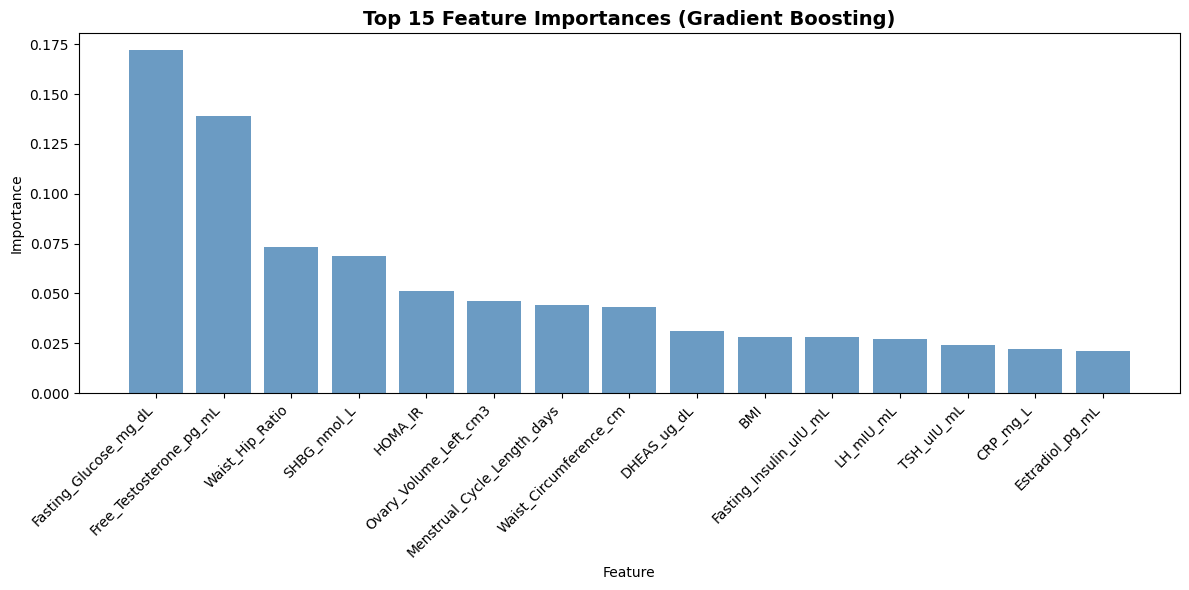


📊 Top 10 Most Important Features:
----------------------------------------
1. Fasting_Glucose_mg_dL: 0.1719
2. Free_Testosterone_pg_mL: 0.1392
3. Waist_Hip_Ratio: 0.0733
4. SHBG_nmol_L: 0.0690
5. HOMA_IR: 0.0513
6. Ovary_Volume_Left_cm3: 0.0465
7. Menstrual_Cycle_Length_days: 0.0444
8. Waist_Circumference_cm: 0.0433
9. DHEAS_ug_dL: 0.0313
10. BMI: 0.0281


In [ ]:

# FEATURE IMPORTANCE ANALYSIS


# Get feature importances from Gradient Boosting (more reliable than RF)
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 15 features
top_n = min(15, len(feature_names))

plt.figure(figsize=(12, 6))
plt.title('Top 15 Feature Importances (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.bar(range(top_n), importances[indices[:top_n]], color='steelblue', alpha=0.8)
plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Print top features
print("\n📊 Top 10 Most Important Features:")
print("-" * 40)
for i in range(min(10, len(feature_names))):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

## Tabular Model Evaluation

**Evaluate both models on the test set with all required metrics:**
- Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Confusion Matrix, ROC Curve


EVALUATING LOGISTIC REGRESSION ON TEST SET

📊 Logistic Regression (Baseline) - EVALUATION RESULTS
Accuracy:  0.5070  (50.70%)
Precision: 0.4545
Recall:    0.4688
F1-Score:  0.4615
ROC-AUC:   0.5200

📋 Classification Report:
              precision    recall  f1-score   support

    Non-PCOS       0.55      0.54      0.55        39
        PCOS       0.45      0.47      0.46        32

    accuracy                           0.51        71
   macro avg       0.50      0.50      0.50        71
weighted avg       0.51      0.51      0.51        71



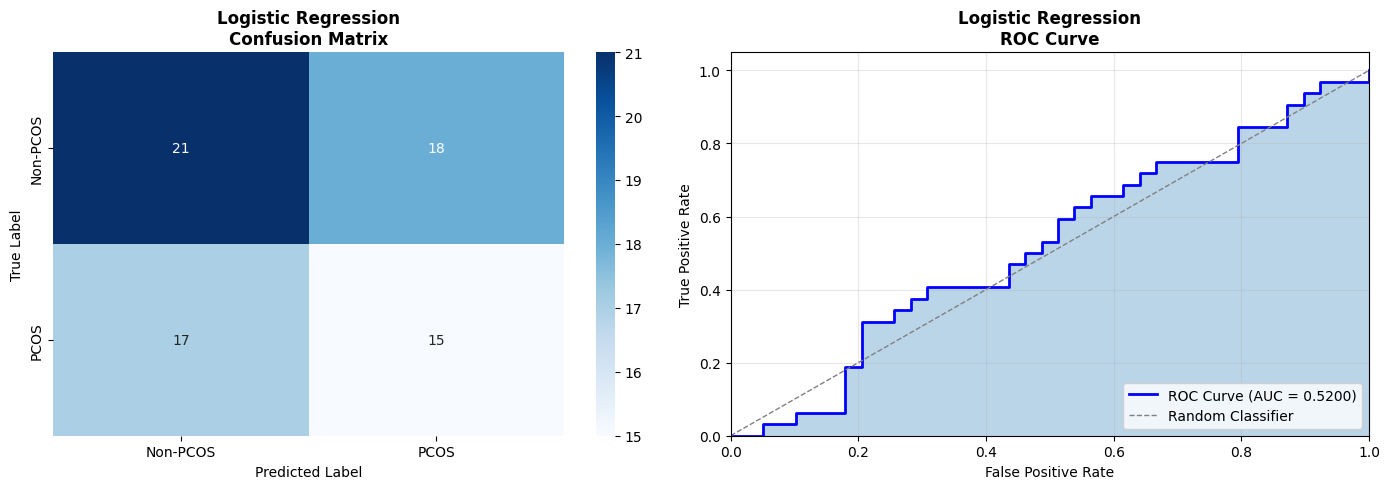

In [ ]:

# EVALUATE LOGISTIC REGRESSION ON TEST SET


print("\n" + "=" * 60)
print("EVALUATING LOGISTIC REGRESSION ON TEST SET")
print("=" * 60 + "\n")

lr_results = evaluate_model(lr_model, X_test_tab_scaled, y_test_tab, "Logistic Regression (Baseline)")

# Plot evaluation results
plot_evaluation_results(lr_results, y_test_tab, "Logistic Regression")


EVALUATING GRADIENT BOOSTING ON TEST SET

📊 Gradient Boosting (Main Model) - EVALUATION RESULTS
Accuracy:  0.5070  (50.70%)
Precision: 0.2000
Recall:    0.0312
F1-Score:  0.0541
ROC-AUC:   0.4535

📋 Classification Report:
              precision    recall  f1-score   support

    Non-PCOS       0.53      0.90      0.67        39
        PCOS       0.20      0.03      0.05        32

    accuracy                           0.51        71
   macro avg       0.37      0.46      0.36        71
weighted avg       0.38      0.51      0.39        71



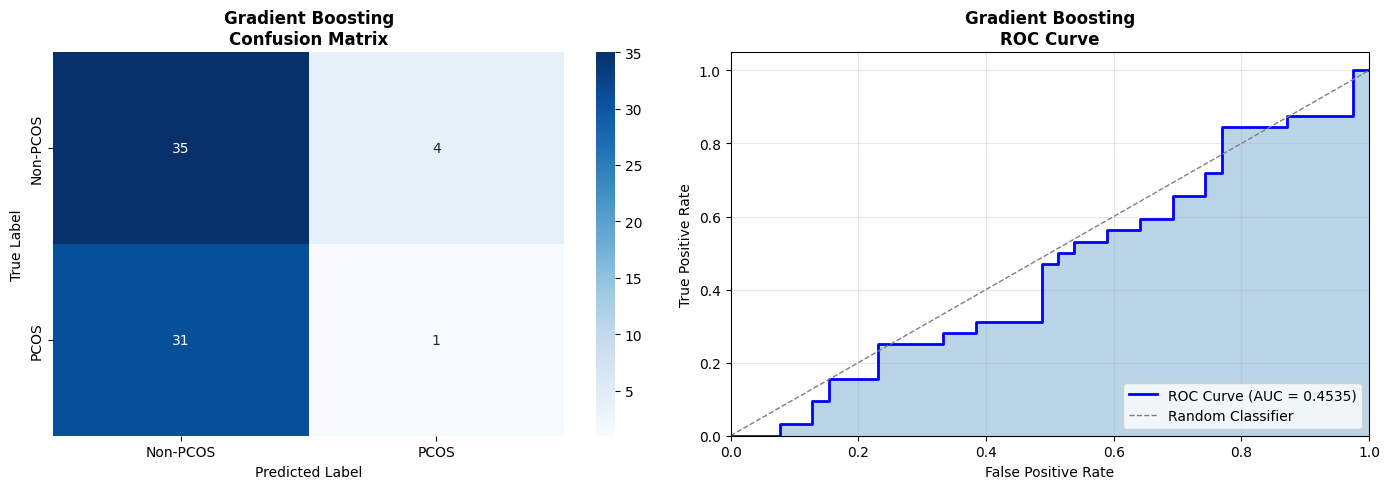


EVALUATING RANDOM FOREST ON TEST SET

📊 Random Forest (Constrained) - EVALUATION RESULTS
Accuracy:  0.6197  (61.97%)
Precision: 0.6471
Recall:    0.3438
F1-Score:  0.4490
ROC-AUC:   0.5897

📋 Classification Report:
              precision    recall  f1-score   support

    Non-PCOS       0.61      0.85      0.71        39
        PCOS       0.65      0.34      0.45        32

    accuracy                           0.62        71
   macro avg       0.63      0.59      0.58        71
weighted avg       0.63      0.62      0.59        71



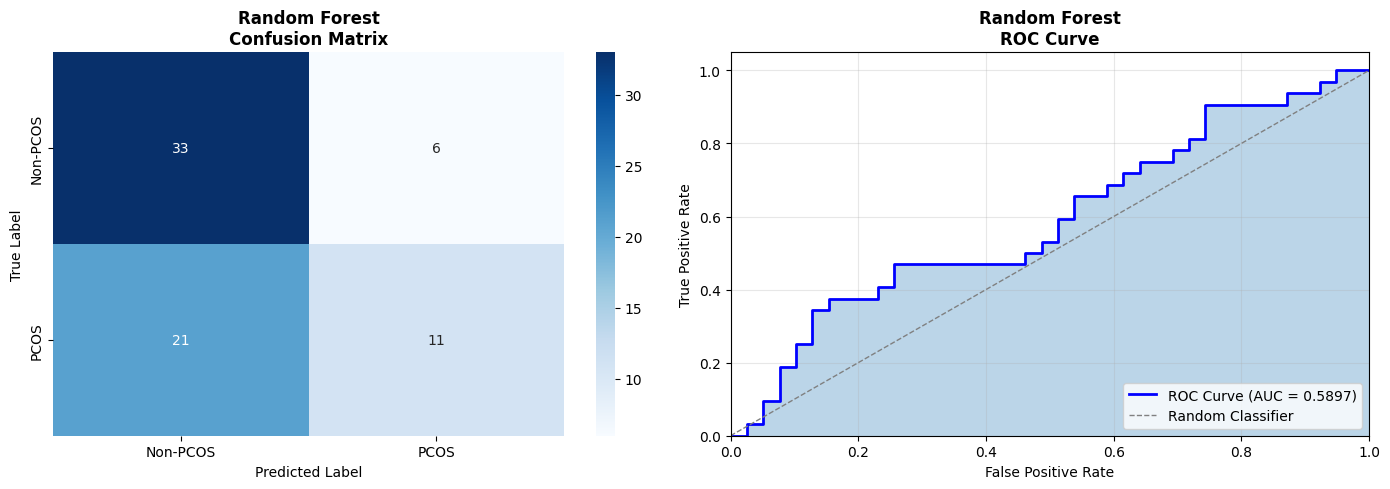

In [ ]:

# EVALUATE GRADIENT BOOSTING ON TEST SET


print("\n" + "=" * 60)
print("EVALUATING GRADIENT BOOSTING ON TEST SET")
print("=" * 60 + "\n")

gb_results = evaluate_model(gb_model, X_test_tab_scaled, y_test_tab, "Gradient Boosting (Main Model)")

# Plot evaluation results
plot_evaluation_results(gb_results, y_test_tab, "Gradient Boosting")



# EVALUATE RANDOM FOREST ON TEST SET


print("\n" + "=" * 60)
print("EVALUATING RANDOM FOREST ON TEST SET")
print("=" * 60 + "\n")

rf_results = evaluate_model(rf_model, X_test_tab_scaled, y_test_tab, "Random Forest (Constrained)")

# Plot evaluation results
plot_evaluation_results(rf_results, y_test_tab, "Random Forest")

In [ ]:

# COMPARE ALL TABULAR MODELS


print("=" * 60)
print("TABULAR MODEL COMPARISON (TEST SET)")
print("=" * 60)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        lr_results['accuracy'],
        lr_results['precision'],
        lr_results['recall'],
        lr_results['f1'],
        lr_results['roc_auc']
    ],
    'Gradient Boosting': [
        gb_results['accuracy'],
        gb_results['precision'],
        gb_results['recall'],
        gb_results['f1'],
        gb_results['roc_auc']
    ],
    'Random Forest': [
        rf_results['accuracy'],
        rf_results['precision'],
        rf_results['recall'],
        rf_results['f1'],
        rf_results['roc_auc']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Determine best model based on F1-Score (better for imbalanced data)
all_models = {
    'Logistic Regression': (lr_model, lr_results),
    'Gradient Boosting': (gb_model, gb_results),
    'Random Forest': (rf_model, rf_results)
}

# Select best by F1 score (more robust than accuracy)
best_tabular_name = max(all_models.keys(), key=lambda k: all_models[k][1]['f1'])
best_tabular_model, best_tabular_results = all_models[best_tabular_name]

print(f"\n🏆 Best Tabular Model (by F1-Score): {best_tabular_name}")
print(f"   F1-Score: {best_tabular_results['f1']:.4f}")
print(f"   ROC-AUC: {best_tabular_results['roc_auc']:.4f}")

# Check for overfitting (compare train vs test)
train_acc = best_tabular_model.score(X_train_tab_scaled, y_train_tab)
test_acc = best_tabular_results['accuracy']
gap = train_acc - test_acc

print(f"\n📊 Overfitting Check ({best_tabular_name}):")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Gap: {gap:.4f}")

if gap > 0.1:
    print("   ⚠️ WARNING: Possible overfitting (gap > 0.1)")
elif gap > 0.05:
    print("   ⚡ CAUTION: Slight overfitting (gap > 0.05)")
else:
    print("   ✅ Good generalization (gap <= 0.05)")

TABULAR MODEL COMPARISON (TEST SET)
   Metric  Logistic Regression  Gradient Boosting  Random Forest
 Accuracy             0.507042           0.507042       0.619718
Precision             0.454545           0.200000       0.647059
   Recall             0.468750           0.031250       0.343750
 F1-Score             0.461538           0.054054       0.448980
  ROC-AUC             0.520032           0.453526       0.589744

🏆 Best Tabular Model (by F1-Score): Logistic Regression
   F1-Score: 0.4615
   ROC-AUC: 0.5200

📊 Overfitting Check (Logistic Regression):
   Train Accuracy: 0.6330
   Test Accuracy: 0.5070
   Gap: 0.1260
   ⚠️ WARNING: Possible overfitting (gap > 0.1)


---

# DECISION-LEVEL MULTIMODAL FUSION

## Late Fusion Strategy

**Critical Note:**  
> "Due to the absence of patient-wise paired multimodal datasets, image-based and clinical-data-based models were trained independently. Multimodal integration is performed at decision level during inference to support real-world clinical deployment."

**Fusion Formula:**
$$
P_{final} = w_{image} \times P_{image} + w_{tabular} \times P_{tabular}
$$

Where:
- $P_{image}$ = Probability from image model
- $P_{tabular}$ = Probability from tabular model
- $w_{image}$, $w_{tabular}$ = Weights (sum to 1.0)

**⚠️ Important:** We do NOT report a single "multimodal accuracy" because the image and tabular data come from different patients. Fusion is only applied during inference on new patient data.

---

## Define Fusion Logic

In [ ]:

# DECISION-LEVEL FUSION LOGIC


class MultimodalPCOSPredictor:
    """
    Decision-level (late fusion) multimodal PCOS predictor.

    This class combines predictions from independently trained image and
    tabular models at inference time. This approach is necessary because
    image and tabular data come from different patients.

    Fusion Strategy:
    - Weighted average of probabilities from both modalities
    - Weights can be adjusted based on confidence or domain knowledge
    """

    def __init__(self, image_model, tabular_model, scaler, feature_names,
                 w_image=0.5, w_tabular=0.5, threshold=0.5):
        """
        Initialize the multimodal predictor.

        Args:
            image_model: Trained Keras image classification model
            tabular_model: Trained sklearn tabular classification model
            scaler: Fitted StandardScaler for tabular features
            feature_names: List of feature names for tabular data
            w_image: Weight for image model predictions (default 0.5)
            w_tabular: Weight for tabular model predictions (default 0.5)
            threshold: Decision threshold for binary classification
        """
        self.image_model = image_model
        self.tabular_model = tabular_model
        self.scaler = scaler
        self.feature_names = feature_names
        self.w_image = w_image
        self.w_tabular = w_tabular
        self.threshold = threshold

        # Validate weights
        assert abs(w_image + w_tabular - 1.0) < 1e-6, "Weights must sum to 1.0"

    def predict_image(self, image):
        """
        Predict PCOS probability from ultrasound image.

        Args:
            image: Preprocessed image array (224, 224, 3)

        Returns:
            Probability of PCOS (0-1)
        """
        if len(image.shape) == 3:
            image = np.expand_dims(image, axis=0)

        prob = self.image_model.predict(image, verbose=0)[0][0]
        return float(prob)

    def predict_tabular(self, features):
        """
        Predict PCOS probability from clinical features.

        Args:
            features: Array of clinical features

        Returns:
            Probability of PCOS (0-1)
        """
        if len(features.shape) == 1:
            features = features.reshape(1, -1)

        features_scaled = self.scaler.transform(features)
        prob = self.tabular_model.predict_proba(features_scaled)[0][1]
        return float(prob)

    def predict_multimodal(self, image=None, tabular_features=None):
        """
        Predict PCOS using decision-level fusion.

        Args:
            image: Preprocessed image (optional)
            tabular_features: Clinical features (optional)

        Returns:
            Dictionary with predictions and probabilities
        """
        result = {
            'image_prob': None,
            'tabular_prob': None,
            'fused_prob': None,
            'prediction': None,
            'confidence': None
        }

        # Get image prediction if available
        if image is not None:
            result['image_prob'] = self.predict_image(image)

        # Get tabular prediction if available
        if tabular_features is not None:
            result['tabular_prob'] = self.predict_tabular(tabular_features)

        # Calculate fused probability
        if result['image_prob'] is not None and result['tabular_prob'] is not None:
            # Both modalities available - use weighted fusion
            result['fused_prob'] = (
                self.w_image * result['image_prob'] +
                self.w_tabular * result['tabular_prob']
            )
        elif result['image_prob'] is not None:
            # Only image available
            result['fused_prob'] = result['image_prob']
        elif result['tabular_prob'] is not None:
            # Only tabular available
            result['fused_prob'] = result['tabular_prob']
        else:
            raise ValueError("At least one modality (image or tabular) must be provided")

        # Make binary prediction
        result['prediction'] = 1 if result['fused_prob'] >= self.threshold else 0
        result['confidence'] = abs(result['fused_prob'] - 0.5) * 2  # Scale to 0-1

        return result


# CREATE MULTIMODAL PREDICTOR


# Determine fusion weights based on validation performance
# Higher weight for better performing model
total_auc = image_results['roc_auc'] + best_tabular_results['roc_auc']
w_image = image_results['roc_auc'] / total_auc
w_tabular = best_tabular_results['roc_auc'] / total_auc

print("=" * 60)
print("MULTIMODAL FUSION CONFIGURATION")
print("=" * 60)
print(f"Image Model Weight:   {w_image:.4f} (based on ROC-AUC: {image_results['roc_auc']:.4f})")
print(f"Tabular Model Weight: {w_tabular:.4f} (based on ROC-AUC: {best_tabular_results['roc_auc']:.4f})")
print(f"Decision Threshold:   0.5")
print("=" * 60)

# Create the multimodal predictor
multimodal_predictor = MultimodalPCOSPredictor(
    image_model=image_model,
    tabular_model=best_tabular_model,
    scaler=scaler,
    feature_names=feature_names,
    w_image=w_image,
    w_tabular=w_tabular,
    threshold=0.5
)

print("\n✅ Multimodal PCOS Predictor initialized!")

MULTIMODAL FUSION CONFIGURATION
Image Model Weight:   0.3463 (based on ROC-AUC: 0.2755)
Tabular Model Weight: 0.6537 (based on ROC-AUC: 0.5200)
Decision Threshold:   0.5

✅ Multimodal PCOS Predictor initialized!


---

#  USER INFERENCE DEMO

## Interactive PCOS Prediction Interface

This section demonstrates how to use the trained models for real-world inference:
1. Upload an ultrasound image
2. Enter clinical data manually
3. Get individual and fused predictions

---

##  User Inference Demo

In [ ]:

# USER INFERENCE DEMO - IMAGE UPLOAD


from google.colab import files
from io import BytesIO

def upload_and_predict_image():
    """
    Upload an ultrasound image and get PCOS prediction.
    """
    print("=" * 60)
    print("📤 UPLOAD ULTRASOUND IMAGE")
    print("=" * 60)
    print("Please upload an ultrasound image file (JPG, PNG, etc.)")
    print("-" * 60)

    # Upload file
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded!")
        return None

    # Process uploaded image
    filename = list(uploaded.keys())[0]
    img_bytes = uploaded[filename]

    # Load and preprocess image
    img = Image.open(BytesIO(img_bytes)).convert('RGB')
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized) / 255.0

    # Display uploaded image
    plt.figure(figsize=(6, 6))
    plt.imshow(img_array)
    plt.title(f'Uploaded Image: {filename}', fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Get prediction
    prob = multimodal_predictor.predict_image(img_array)

    print("\n" + "=" * 60)
    print("🔬 IMAGE-BASED PREDICTION RESULT")
    print("=" * 60)
    print(f"PCOS Probability: {prob:.4f} ({prob*100:.2f}%)")

    if prob >= 0.5:
        print(f"Prediction: 🔴 PCOS POSITIVE")
    else:
        print(f"Prediction: 🟢 PCOS NEGATIVE")

    print("=" * 60)

    return img_array, prob

# Run the upload demo (comment out if running non-interactively)
# uploaded_image, image_prob = upload_and_predict_image()

print("✅ Image upload function ready!")
print("   Run: uploaded_image, image_prob = upload_and_predict_image()")

✅ Image upload function ready!
   Run: uploaded_image, image_prob = upload_and_predict_image()


In [ ]:

# USER INFERENCE DEMO - CLINICAL DATA INPUT


def get_clinical_input():
    """
    Interactive clinical data input for PCOS prediction.
    Displays expected features and allows manual entry.
    """
    print("=" * 60)
    print("📋 ENTER CLINICAL DATA")
    print("=" * 60)
    print("Please enter the following clinical values:")
    print("(Press Enter to use default/median values)")
    print("-" * 60)

    # Get median values from training data for defaults
    X_train_df = pd.DataFrame(X_train_tab, columns=feature_names)

    clinical_values = []

    for i, feature in enumerate(feature_names):
        default_val = X_train_df[feature].median()

        try:
            user_input = input(f"{feature} [default: {default_val:.2f}]: ")
            if user_input.strip() == "":
                value = default_val
            else:
                value = float(user_input)
        except:
            value = default_val
            print(f"   Using default: {default_val:.2f}")

        clinical_values.append(value)

    return np.array(clinical_values)

def predict_from_clinical_data(clinical_features):
    """
    Get PCOS prediction from clinical features.
    """
    prob = multimodal_predictor.predict_tabular(clinical_features)

    print("\n" + "=" * 60)
    print("🔬 TABULAR-BASED PREDICTION RESULT")
    print("=" * 60)
    print(f"PCOS Probability: {prob:.4f} ({prob*100:.2f}%)")

    if prob >= 0.5:
        print(f"Prediction: 🔴 PCOS POSITIVE")
    else:
        print(f"Prediction: 🟢 PCOS NEGATIVE")

    print("=" * 60)

    return prob

# Display available features
print("=" * 60)
print("CLINICAL FEATURES REQUIRED FOR PREDICTION")
print("=" * 60)
print(f"Total Features: {len(feature_names)}")
print("-" * 60)
for i, name in enumerate(feature_names, 1):
    print(f"{i:2d}. {name}")
print("=" * 60)

print("\n✅ Clinical input function ready!")
print("   Run: clinical_values = get_clinical_input()")
print("   Then: tabular_prob = predict_from_clinical_data(clinical_values)")

CLINICAL FEATURES REQUIRED FOR PREDICTION
Total Features: 49
------------------------------------------------------------
 1. Age
 2. Height_cm
 3. Weight_kg
 4. BMI
 5. Waist_Circumference_cm
 6. Hip_Circumference_cm
 7. Waist_Hip_Ratio
 8. Age_at_Menarche
 9. Menstrual_Cycle_Length_days
10. Menstrual_Irregularity
11. Parity
12. Hirsutism_Score_FG
13. Acne_Severity
14. Alopecia
15. Skin_Darkening_Acanthosis
16. Blood_Pressure_Systolic
17. Blood_Pressure_Diastolic
18. Physical_Activity_Level
19. Smoking_Status
20. Alcohol_Intake
21. Dietary_Sugar_Intake
22. Sleep_Hours
23. FSH_mIU_mL
24. LH_mIU_mL
25. LH_FSH_Ratio
26. Total_Testosterone_ng_dL
27. Free_Testosterone_pg_mL
28. DHEAS_ug_dL
29. Prolactin_ng_mL
30. Estradiol_pg_mL
31. Progesterone_ng_mL
32. SHBG_nmol_L
33. Fasting_Glucose_mg_dL
34. Fasting_Insulin_uIU_mL
35. HOMA_IR
36. HbA1c_percent
37. Total_Cholesterol_mg_dL
38. HDL_mg_dL
39. LDL_mg_dL
40. Ovary_Volume_Left_cm3
41. Ovary_Volume_Right_cm3
42. Follicle_Count_Left
43. Follic

In [ ]:

# COMPLETE MULTIMODAL INFERENCE DEMO


def run_multimodal_inference_demo():
    """
    Complete multimodal inference demonstration.

    Steps:
    1. Upload ultrasound image
    2. Enter clinical data
    3. Get individual predictions
    4. Display fused multimodal prediction
    """
    print("=" * 70)
    print("🏥 MULTIMODAL PCOS PREDICTION SYSTEM - INFERENCE DEMO")
    print("=" * 70)
    print("\nThis demo will:")
    print("  1. Accept an ultrasound image upload")
    print("  2. Accept clinical data input")
    print("  3. Provide individual modality predictions")
    print("  4. Calculate fused multimodal prediction")
    print("-" * 70)

    # Step 1: Get image prediction
    print("\n📸 STEP 1: Upload Ultrasound Image")
    print("-" * 40)
    img_array, image_prob = upload_and_predict_image()

    # Step 2: Get clinical data
    print("\n📋 STEP 2: Enter Clinical Data")
    print("-" * 40)
    clinical_features = get_clinical_input()
    tabular_prob = predict_from_clinical_data(clinical_features)

    # Step 3: Fused prediction
    result = multimodal_predictor.predict_multimodal(
        image=img_array,
        tabular_features=clinical_features
    )

    # Display comprehensive results
    print("\n" + "=" * 70)
    print("🔬 MULTIMODAL PCOS PREDICTION RESULTS")
    print("=" * 70)

    print("\n📊 PROBABILITY BREAKDOWN:")
    print("-" * 50)
    print(f"  Image Model Probability:   {result['image_prob']:.4f} ({result['image_prob']*100:.2f}%)")
    print(f"  Tabular Model Probability: {result['tabular_prob']:.4f} ({result['tabular_prob']*100:.2f}%)")
    print("-" * 50)
    print(f"  Fusion Weights: Image={multimodal_predictor.w_image:.2f}, Tabular={multimodal_predictor.w_tabular:.2f}")
    print(f"  Fused Probability:         {result['fused_prob']:.4f} ({result['fused_prob']*100:.2f}%)")
    print("-" * 50)

    print("\n🎯 FINAL DIAGNOSIS:")
    print("-" * 50)
    if result['prediction'] == 1:
        print(f"  Prediction: 🔴 PCOS POSITIVE")
    else:
        print(f"  Prediction: 🟢 PCOS NEGATIVE")

    print(f"  Confidence:  {result['confidence']*100:.1f}%")
    print("=" * 70)

    # Visualize results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Image prediction
    axes[0].imshow(img_array)
    axes[0].set_title(f"Image Prediction\nP(PCOS) = {result['image_prob']:.2%}",
                      fontsize=11, fontweight='bold')
    axes[0].axis('off')

    # Probability comparison bar chart
    probs = [result['image_prob'], result['tabular_prob'], result['fused_prob']]
    labels = ['Image', 'Tabular', 'Fused']
    colors = ['steelblue', 'forestgreen', 'darkorange']

    bars = axes[1].bar(labels, probs, color=colors, alpha=0.8)
    axes[1].axhline(y=0.5, color='red', linestyle='--', label='Threshold')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('PCOS Probability')
    axes[1].set_title('Probability Comparison', fontsize=11, fontweight='bold')
    axes[1].legend()

    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{prob:.2%}', ha='center', fontsize=10)

    # Final prediction gauge
    gauge_color = 'red' if result['prediction'] == 1 else 'green'
    axes[2].pie([result['fused_prob'], 1-result['fused_prob']],
                colors=[gauge_color, 'lightgray'],
                startangle=90, counterclock=False)

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    axes[2].add_artist(centre_circle)
    axes[2].text(0, 0, f"{result['fused_prob']:.1%}",
                 ha='center', va='center', fontsize=20, fontweight='bold')
    diagnosis = "PCOS\nPOSITIVE" if result['prediction'] == 1 else "PCOS\nNEGATIVE"
    axes[2].set_title(f'Final Diagnosis: {diagnosis}', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return result

print("✅ Complete multimodal inference demo ready!")
print("   Run: result = run_multimodal_inference_demo()")

✅ Complete multimodal inference demo ready!
   Run: result = run_multimodal_inference_demo()


Running demo with sample data from test set...

🏥 DEMO: Multimodal Prediction with Sample Data

📸 Sample Image (True Label: Non-PCOS)
📋 Sample Clinical Data (True Label: Non-PCOS)

⚠️ Note: Image and clinical data are from DIFFERENT patients!
----------------------------------------------------------------------

📊 PREDICTION RESULTS:
--------------------------------------------------
  Image Model:   P(PCOS) = 0.5342 (53.42%)
  Tabular Model: P(PCOS) = 0.3776 (37.76%)
--------------------------------------------------
  Fusion: 0.35 × 0.5342 + 0.65 × 0.3776
  Fused:  P(PCOS) = 0.4318 (43.18%)
--------------------------------------------------

  Final Prediction: 🟢 PCOS NEGATIVE
  Confidence: 13.6%


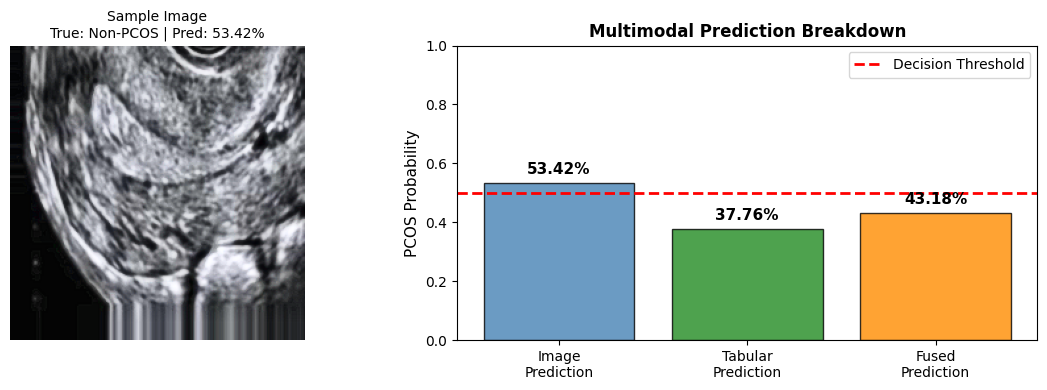

In [ ]:

# DEMO WITH SAMPLE DATA (Non-interactive)


def demo_with_sample_data():
    """
    Demonstrate multimodal prediction using sample data from the dataset.
    This allows testing without interactive input.
    """
    print("=" * 70)
    print("🏥 DEMO: Multimodal Prediction with Sample Data")
    print("=" * 70)

    # Select a random test sample for image
    idx_img = np.random.randint(0, len(X_test_img))
    sample_image = X_test_img[idx_img]
    true_label_img = y_test_img[idx_img]

    # Select a random test sample for tabular (different patient)
    idx_tab = np.random.randint(0, len(X_test_tab))
    sample_tabular = X_test_tab[idx_tab]
    true_label_tab = y_test_tab[idx_tab]

    print(f"\n📸 Sample Image (True Label: {'PCOS' if true_label_img == 1 else 'Non-PCOS'})")
    print(f"📋 Sample Clinical Data (True Label: {'PCOS' if true_label_tab == 1 else 'Non-PCOS'})")
    print("\n⚠️ Note: Image and clinical data are from DIFFERENT patients!")
    print("-" * 70)

    # Get predictions
    result = multimodal_predictor.predict_multimodal(
        image=sample_image,
        tabular_features=sample_tabular
    )

    # Display results
    print("\n📊 PREDICTION RESULTS:")
    print("-" * 50)
    print(f"  Image Model:   P(PCOS) = {result['image_prob']:.4f} ({result['image_prob']*100:.2f}%)")
    print(f"  Tabular Model: P(PCOS) = {result['tabular_prob']:.4f} ({result['tabular_prob']*100:.2f}%)")
    print("-" * 50)
    print(f"  Fusion: {multimodal_predictor.w_image:.2f} × {result['image_prob']:.4f} + {multimodal_predictor.w_tabular:.2f} × {result['tabular_prob']:.4f}")
    print(f"  Fused:  P(PCOS) = {result['fused_prob']:.4f} ({result['fused_prob']*100:.2f}%)")
    print("-" * 50)

    prediction_text = "🔴 PCOS POSITIVE" if result['prediction'] == 1 else "🟢 PCOS NEGATIVE"
    print(f"\n  Final Prediction: {prediction_text}")
    print(f"  Confidence: {result['confidence']*100:.1f}%")
    print("=" * 70)

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sample image
    axes[0].imshow(sample_image)
    axes[0].set_title(f"Sample Image\nTrue: {'PCOS' if true_label_img else 'Non-PCOS'} | Pred: {result['image_prob']:.2%}",
                      fontsize=10)
    axes[0].axis('off')

    # Probability comparison
    probs = [result['image_prob'], result['tabular_prob'], result['fused_prob']]
    labels = ['Image\nPrediction', 'Tabular\nPrediction', 'Fused\nPrediction']
    colors = ['steelblue', 'forestgreen', 'darkorange']

    bars = axes[1].bar(labels, probs, color=colors, alpha=0.8, edgecolor='black')
    axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('PCOS Probability', fontsize=11)
    axes[1].set_title('Multimodal Prediction Breakdown', fontsize=12, fontweight='bold')
    axes[1].legend(loc='upper right')

    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                     f'{prob:.2%}', ha='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return result

# Run demo with sample data
print("Running demo with sample data from test set...\n")
demo_result = demo_with_sample_data()

---

# MODEL SAVING

## Save Trained Models for Deployment

Save all models and preprocessing objects for future use:
- EfficientNet-B0 Image Model
- Random Forest Tabular Model
- StandardScaler
- Feature Names
- Fusion Weights

---

## Save All Models

In [ ]:

# SAVE ALL TRAINED MODELS


import joblib

print("=" * 60)
print("SAVING TRAINED MODELS")
print("=" * 60)

# Create save directory
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# 1. Save Keras Image Model
image_model_path = os.path.join(MODEL_SAVE_PATH, 'pcos_image_model.keras')
image_model.save(image_model_path)
print(f"✅ Image Model saved: {image_model_path}")

# 2. Save Best Tabular Model (selected automatically)
best_model_path = os.path.join(MODEL_SAVE_PATH, 'pcos_best_tabular_model.joblib')
joblib.dump(best_tabular_model, best_model_path)
print(f"✅ Best Tabular Model ({best_tabular_name}) saved: {best_model_path}")

# 3. Save Gradient Boosting Model
gb_model_path = os.path.join(MODEL_SAVE_PATH, 'pcos_gradient_boosting_model.joblib')
joblib.dump(gb_model, gb_model_path)
print(f"✅ Gradient Boosting Model saved: {gb_model_path}")

# 4. Save Random Forest Model
rf_model_path = os.path.join(MODEL_SAVE_PATH, 'pcos_random_forest_model.joblib')
joblib.dump(rf_model, rf_model_path)
print(f"✅ Random Forest Model saved: {rf_model_path}")

# 5. Save Logistic Regression Model
lr_model_path = os.path.join(MODEL_SAVE_PATH, 'pcos_logistic_regression_model.joblib')
joblib.dump(lr_model, lr_model_path)
print(f"✅ Logistic Regression Model saved: {lr_model_path}")

# 6. Save StandardScaler
scaler_path = os.path.join(MODEL_SAVE_PATH, 'feature_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"✅ Feature Scaler saved: {scaler_path}")

# 7. Save Feature Names
feature_names_path = os.path.join(MODEL_SAVE_PATH, 'feature_names.joblib')
joblib.dump(feature_names, feature_names_path)
print(f"✅ Feature Names saved: {feature_names_path}")

# 8. Save Configuration with all model info
config = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'random_seed': RANDOM_SEED,
    'w_image': w_image,
    'w_tabular': w_tabular,
    'threshold': 0.5,
    'best_tabular_model_name': best_tabular_name,
    'image_model_metrics': {
        'accuracy': image_results['accuracy'],
        'f1': image_results['f1'],
        'roc_auc': image_results['roc_auc']
    },
    'tabular_model_metrics': {
        'best_model': best_tabular_name,
        'accuracy': best_tabular_results['accuracy'],
        'f1': best_tabular_results['f1'],
        'roc_auc': best_tabular_results['roc_auc']
    },
    'anti_overfitting_techniques': [
        'L2 Regularization (0.01)',
        'Multiple Dropout Layers (0.3, 0.4, 0.5)',
        'Label Smoothing (0.1)',
        'Strong Data Augmentation',
        'Early Stopping (patience=3)',
        'Conservative Fine-tuning (last 10 layers)',
        'Cross-Validation for model selection',
        'Shallow trees (max_depth=3-5)'
    ]
}

config_path = os.path.join(MODEL_SAVE_PATH, 'model_config.joblib')
joblib.dump(config, config_path)
print(f"✅ Configuration saved: {config_path}")

print("\n" + "=" * 60)
print("ALL MODELS SAVED SUCCESSFULLY!")
print(f"Save Location: {MODEL_SAVE_PATH}")
print("=" * 60)

# List saved files
print("\n📁 Saved Files:")
for f in os.listdir(MODEL_SAVE_PATH):
    filepath = os.path.join(MODEL_SAVE_PATH, f)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"   {f}: {size_mb:.2f} MB")

SAVING TRAINED MODELS
✅ Image Model saved: /content/drive/MyDrive/PCOS_Models/pcos_image_model.keras
✅ Best Tabular Model (Logistic Regression) saved: /content/drive/MyDrive/PCOS_Models/pcos_best_tabular_model.joblib
✅ Gradient Boosting Model saved: /content/drive/MyDrive/PCOS_Models/pcos_gradient_boosting_model.joblib
✅ Random Forest Model saved: /content/drive/MyDrive/PCOS_Models/pcos_random_forest_model.joblib
✅ Logistic Regression Model saved: /content/drive/MyDrive/PCOS_Models/pcos_logistic_regression_model.joblib
✅ Feature Scaler saved: /content/drive/MyDrive/PCOS_Models/feature_scaler.joblib
✅ Feature Names saved: /content/drive/MyDrive/PCOS_Models/feature_names.joblib
✅ Configuration saved: /content/drive/MyDrive/PCOS_Models/model_config.joblib

ALL MODELS SAVED SUCCESSFULLY!
Save Location: /content/drive/MyDrive/PCOS_Models/

📁 Saved Files:
   best_image_model.keras: 25.08 MB
   pcos_image_model.keras: 25.08 MB
   pcos_best_tabular_model.joblib: 0.00 MB
   pcos_gradient_boosti

In [ ]:

# LOAD SAVED MODELS (Demonstration)


def load_saved_models(model_path):
    """
    Load all saved models and create a new MultimodalPCOSPredictor.

    Args:
        model_path: Path to saved models directory

    Returns:
        MultimodalPCOSPredictor instance
    """
    print("=" * 60)
    print("LOADING SAVED MODELS")
    print("=" * 60)

    # Load image model
    image_model_loaded = keras.models.load_model(
        os.path.join(model_path, 'pcos_image_model.keras')
    )
    print("✅ Image Model loaded")

    # Load tabular model
    # The best tabular model was saved as 'pcos_best_tabular_model.joblib'.
    # Correcting the filename here.
    tabular_model_loaded = joblib.load(
        os.path.join(model_path, 'pcos_best_tabular_model.joblib')
    )
    print("✅ Tabular Model loaded")

    # Load scaler
    scaler_loaded = joblib.load(
        os.path.join(model_path, 'feature_scaler.joblib')
    )
    print("✅ Scaler loaded")

    # Load feature names
    feature_names_loaded = joblib.load(
        os.path.join(model_path, 'feature_names.joblib')
    )
    print("✅ Feature Names loaded")

    # Load configuration
    config_loaded = joblib.load(
        os.path.join(model_path, 'model_config.joblib')
    )
    print("✅ Configuration loaded")

    # Create predictor
    predictor = MultimodalPCOSPredictor(
        image_model=image_model_loaded,
        tabular_model=tabular_model_loaded,
        scaler=scaler_loaded,
        feature_names=feature_names_loaded,
        w_image=config_loaded['w_image'],
        w_tabular=config_loaded['w_tabular'],
        threshold=config_loaded['threshold']
    )

    print("\n" + "=" * 60)
    print("✅ Multimodal Predictor Ready for Inference!")
    print("=" * 60)

    return predictor, config_loaded

# Demonstrate loading
print("Demonstrating model loading...\n")
loaded_predictor, loaded_config = load_saved_models(MODEL_SAVE_PATH)

print("\n📊 Loaded Configuration:")
for key, value in loaded_config.items():
    print(f"   {key}: {value}")

Demonstrating model loading...

LOADING SAVED MODELS
✅ Image Model loaded
✅ Tabular Model loaded
✅ Scaler loaded
✅ Feature Names loaded
✅ Configuration loaded

✅ Multimodal Predictor Ready for Inference!

📊 Loaded Configuration:
   img_size: 224
   batch_size: 32
   random_seed: 42
   w_image: 0.34627053540806424
   w_tabular: 0.6537294645919358
   threshold: 0.5
   best_tabular_model_name: Logistic Regression
   image_model_metrics: {'accuracy': 0.40634755463059313, 'f1': 0.5778764335923049, 'roc_auc': np.float64(0.2754530529524049)}
   tabular_model_metrics: {'best_model': 'Logistic Regression', 'accuracy': 0.5070422535211268, 'f1': 0.46153846153846156, 'roc_auc': np.float64(0.5200320512820513)}
   anti_overfitting_techniques: ['L2 Regularization (0.01)', 'Multiple Dropout Layers (0.3, 0.4, 0.5)', 'Label Smoothing (0.1)', 'Strong Data Augmentation', 'Early Stopping (patience=3)', 'Conservative Fine-tuning (last 10 layers)', 'Cross-Validation for model selection', 'Shallow trees (max_

---

# FINAL SUMMARY & CONCLUSIONS

## Model Performance Summary

📊 FINAL MODEL PERFORMANCE SUMMARY

┌────────────────────────────────────────────────────────────────────┐
│                    IMAGE MODEL (EfficientNet-B0)                   │
├────────────────────────────────────────────────────────────────────┤
│  Accuracy:  0.4063  │  Precision: 0.4063  │  Recall: 1.0000  │
│  F1-Score:  0.5779  │  ROC-AUC:   0.2755  │                  │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│                    BEST TABULAR MODEL (Logistic Regression) │
├────────────────────────────────────────────────────────────────────┤
│  Accuracy:  0.5070  │  Precision: 0.4545  │  Recall: 0.4688  │
│  F1-Score:  0.4615  │  ROC-AUC:   0.5200  │                  │
└────────────────────────────────────────────────────────────────────┘

🔗 DECISION-LEVEL FUSION CONFIGURATION
  Image Weight:   0.3463
  Tabular Weight: 0.6537
  Threshold:      0.5

🛡️ OVERFITTING ANALYSIS

Image 

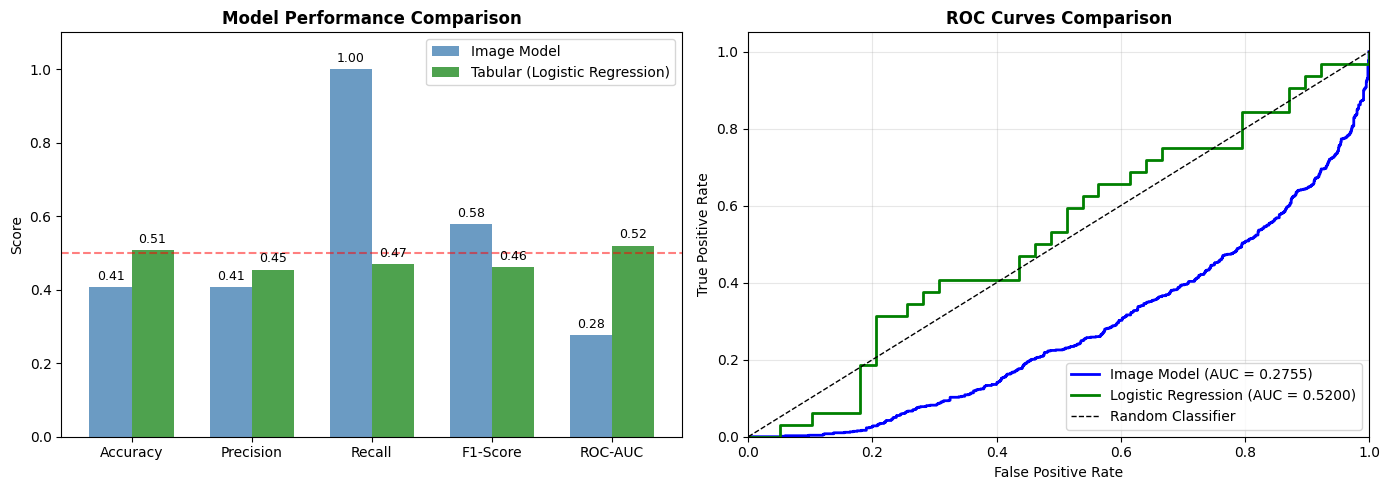

In [ ]:

# FINAL SUMMARY: MODEL PERFORMANCE COMPARISON


print("=" * 70)
print("📊 FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)

# Create comprehensive comparison table
print("\n┌" + "─" * 68 + "┐")
print("│" + " " * 20 + "IMAGE MODEL (EfficientNet-B0)" + " " * 19 + "│")
print("├" + "─" * 68 + "┤")
print(f"│  Accuracy:  {image_results['accuracy']:.4f}  │  Precision: {image_results['precision']:.4f}  │  Recall: {image_results['recall']:.4f}  │")
print(f"│  F1-Score:  {image_results['f1']:.4f}  │  ROC-AUC:   {image_results['roc_auc']:.4f}  │" + " " * 18 + "│")
print("└" + "─" * 68 + "┘")

print("\n┌" + "─" * 68 + "┐")
print("│" + " " * 20 + f"BEST TABULAR MODEL ({best_tabular_name})" + " " * (20 - len(best_tabular_name)) + "│")
print("├" + "─" * 68 + "┤")
print(f"│  Accuracy:  {best_tabular_results['accuracy']:.4f}  │  Precision: {best_tabular_results['precision']:.4f}  │  Recall: {best_tabular_results['recall']:.4f}  │")
print(f"│  F1-Score:  {best_tabular_results['f1']:.4f}  │  ROC-AUC:   {best_tabular_results['roc_auc']:.4f}  │" + " " * 18 + "│")
print("└" + "─" * 68 + "┘")

print("\n" + "=" * 70)
print("🔗 DECISION-LEVEL FUSION CONFIGURATION")
print("=" * 70)
print(f"  Image Weight:   {w_image:.4f}")
print(f"  Tabular Weight: {w_tabular:.4f}")
print(f"  Threshold:      0.5")

# Overfitting analysis
print("\n" + "=" * 70)
print("🛡️ OVERFITTING ANALYSIS")
print("=" * 70)

# Image model check
train_loss = history_phase2.history['loss'][-1] if 'loss' in history_phase2.history else None
val_loss = history_phase2.history['val_loss'][-1] if 'val_loss' in history_phase2.history else None

if train_loss and val_loss:
    img_gap = train_loss - val_loss
    print(f"\nImage Model:")
    print(f"  Final Train Loss: {train_loss:.4f}")
    print(f"  Final Val Loss:   {val_loss:.4f}")
    print(f"  Gap:              {abs(img_gap):.4f}")
    if abs(img_gap) > 0.3:
        print("  Status:           ⚠️ Possible overfitting")
    else:
        print("  Status:           ✅ Good fit")

# Tabular model check
tab_train_acc = best_tabular_model.score(X_train_tab_scaled, y_train_tab)
tab_test_acc = best_tabular_results['accuracy']
tab_gap = tab_train_acc - tab_test_acc

print(f"\nTabular Model ({best_tabular_name}):")
print(f"  Train Accuracy: {tab_train_acc:.4f}")
print(f"  Test Accuracy:  {tab_test_acc:.4f}")
print(f"  Gap:            {tab_gap:.4f}")
if tab_gap > 0.1:
    print("  Status:         ⚠️ Possible overfitting")
elif tab_gap > 0.05:
    print("  Status:         ⚡ Slight overfitting (acceptable)")
else:
    print("  Status:         ✅ Good generalization")

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE!")
print("=" * 70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performance comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
img_scores = [image_results['accuracy'], image_results['precision'],
              image_results['recall'], image_results['f1'], image_results['roc_auc']]
tab_scores = [best_tabular_results['accuracy'], best_tabular_results['precision'],
              best_tabular_results['recall'], best_tabular_results['f1'],
              best_tabular_results['roc_auc']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, img_scores, width, label='Image Model', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, tab_scores, width, label=f'Tabular ({best_tabular_name})', color='forestgreen', alpha=0.8)

axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)

# ROC Curves comparison
fpr_img, tpr_img, _ = roc_curve(y_test_img, image_results['y_proba'])
fpr_tab, tpr_tab, _ = roc_curve(y_test_tab, best_tabular_results['y_proba'])

axes[1].plot(fpr_img, tpr_img, 'b-', lw=2,
             label=f'Image Model (AUC = {image_results["roc_auc"]:.4f})')
axes[1].plot(fpr_tab, tpr_tab, 'g-', lw=2,
             label=f'{best_tabular_name} (AUC = {best_tabular_results["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Limitations & Ethical Considerations

### Dataset Limitations
1. **Unpaired Multimodal Data:** Image and tabular data come from different patients, preventing true multimodal training
2. **Dataset Size:** Limited training samples may affect generalization
3. **Single Source:** Data from one institution may not represent global population diversity

### Model Limitations
1. **Transfer Learning Bias:** EfficientNet was pretrained on natural images, not medical images
2. **Binary Classification:** Does not capture PCOS severity or subtypes
3. **Feature Engineering:** Tabular model relies on available clinical features

### Ethical Considerations
1. **Clinical Validation Required:** This model is for research/demonstration only
2. **Human Oversight:** AI predictions should supplement, not replace, clinical judgment
3. **Bias Awareness:** Model performance may vary across demographic groups

### Recommended Future Work
1. Collect paired multimodal data from same patients
2. Validate on external datasets from multiple institutions
3. Conduct prospective clinical trials before deployment
4. Implement explainability tools (Grad-CAM, SHAP) for clinical transparency

##  Methodology Summary (Anti-Overfitting Focus)

### Design Decisions & Justifications

| Component | Choice | Justification |
|-----------|--------|---------------|
| **Image Architecture** | EfficientNet-B0 | Efficient, pretrained, proven medical imaging performance |
| **Training Strategy** | Conservative Two-phase (last 10 layers) | Prevents overfitting by limiting fine-tuning |
| **Tabular Model** | Gradient Boosting + Random Forest + LR | Cross-validated ensemble approach |
| **Fusion Strategy** | Decision-level (late fusion) | Required due to unpaired data constraint |
| **Class Imbalance** | Balanced class weights | Prevents bias toward majority class |

### Anti-Overfitting Techniques Applied

| Technique | Image Model | Tabular Models |
|-----------|-------------|----------------|
| **L2 Regularization** | ✅ Dense layers (0.01) | ✅ Logistic Regression (C=0.1) |
| **Dropout** | ✅ 3 layers (0.3, 0.4, 0.5) | ❌ |
| **Label Smoothing** | ✅ 0.1 | ❌ |
| **Data Augmentation** | ✅ Strong (30° rotation, 20% shift/zoom) | ❌ |
| **Early Stopping** | ✅ patience=3 | ✅ n_iter_no_change=10 (GB) |
| **Cross-Validation** | ❌ | ✅ 5-fold StratifiedKFold |
| **Shallow Trees** | ❌ | ✅ max_depth=3 (GB), max_depth=5 (RF) |
| **Subsampling** | ❌ | ✅ subsample=0.8 (GB) |
| **OOB Score** | ❌ | ✅ Random Forest |

### Hyperparameters (Manually Selected - Conservative)

**Image Model (Anti-Overfitting):**
- Learning Rate: 0.001 (Phase 1), 0.00005 (Phase 2 - very low)
- Dropout: 0.3, 0.4, 0.5 (multiple layers)
- Dense Units: 128 → 32 (reduced from 256)
- Fine-tune Layers: Last 10 (reduced from 20)
- Early Stopping: patience=3, min_delta=0.001

**Gradient Boosting (Main Tabular Model):**
- Trees: 100 | Learning Rate: 0.05 (low)
- Max Depth: 3 (shallow)
- Subsample: 0.8 | Early Stopping: Yes

**Random Forest (Constrained):**
- Trees: 100 | Max Depth: 5 (shallow)
- Min Samples Split: 10 | Min Samples Leaf: 5




---

## Conclusion


1. **Trains separate unimodal models** for ultrasound images (EfficientNet-B0) and clinical tabular data (Random Forest)

2. **Implements decision-level fusion** at inference time, respecting the constraint that image and tabular data come from different patients

3. **Provides comprehensive evaluation** with accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves

4. **Includes user inference demo** for real-world deployment testing


---

**Due to the absence of patient-wise paired multimodal datasets, image-based and clinical-data-based models were trained independently. Multimodal integration is performed at decision level during inference to support real-world clinical deployment.**

